In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy.signal import residue
from scipy.linalg import matmul_toeplitz
from tqdm import tqdm
import scienceplots

plt.style.use(["science"])
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams.update({
    "axes.labelsize": 18,    # x- and y-label size
    "axes.titlesize": 18,    # title size
    "xtick.labelsize": 15,   # x-tick label size
    "ytick.labelsize": 15,   # y-tick label size
    "legend.fontsize": 34,   # legend text size
})

# FUNCTIONS

In [3]:
# ==========================================
# 1. HELPER FUNCTIONS & INVERSE LAPLACE
# ==========================================
def coth(z):
    z = np.asarray(z, dtype=np.complex128)
    out = np.empty_like(z)

    r = np.real(z)

    pos = r > 20
    neg = r < -20
    mid = ~(pos | neg)

    out[pos] = 1.0 + 2*np.exp(-2*z[pos])
    out[neg] = -1.0 - 2*np.exp(2*z[neg])
    out[mid] = np.cosh(z[mid])/np.sinh(z[mid])

    return out.item() if out.ndim == 0 else out


def csch2(z):
    z = np.asarray(z, dtype=np.complex128)
    out = np.empty_like(z)

    r = np.real(z)

    large = np.abs(r) > 20
    small = ~large

    out[large] = 4*np.exp(-2*np.abs(r[large]))*np.exp(-2j*np.imag(z[large])*0)

    s = np.sinh(z[small])
    out[small] = 1/(s*s)

    return out.item() if out.ndim == 0 else out

def inverse_laplace_rational(B, A, enforce_real=True):
    B = np.atleast_1d(np.array(B, dtype=np.complex128))
    A = np.atleast_1d(np.array(A, dtype=np.complex128))
    r, p, k = residue(B, A)

    info = {"residues": r, "poles": p, "direct_poly": k}
    return info

def derivatives_from_residues(t, residues, poles, enforce_real=True):
    t = np.asarray(t, dtype=float)

    G    = np.zeros_like(t, dtype=np.complex128)
    Gdot = np.zeros_like(t, dtype=np.complex128)
    Gddot= np.zeros_like(t, dtype=np.complex128)

    for r, p in zip(residues, poles):
        ep = np.exp(p * t)
        G     += r * ep
        Gdot  += r * p * ep
        Gddot += r * p * p * ep

    if enforce_real:
        G     = np.real_if_close(G)
        Gdot  = np.real_if_close(Gdot)
        Gddot = np.real_if_close(Gddot)

    return G, Gdot, Gddot

# ==========================================
# 2. NOISE KERNEL & TEMPERATURE DERIVATIVE
# ==========================================
def noise_kernel_residue(t, gamma, alpha1, alpha2, Temp, Nmats=50000, delta_eps=1e-10):
    scalar_input = np.isscalar(t)
    t = np.atleast_1d(np.asarray(t, dtype=np.float64))
    t = np.abs(t)
    
    Delta = 4.0 * alpha2 * gamma - gamma**2
    beta = 1.0 / Temp
    a = 0.5 * beta

    if abs(Delta) < delta_eps:
        w0 = 0.5j * gamma
        exp0 = np.exp(1j * w0 * t)
        coth0 = coth(a * w0)
        fprime = (a * (-csch2(a * w0)) + 1j * t * coth0) * exp0
        nu_sys = (np.pi * gamma * alpha1 * alpha2 / 2.0) * np.real(fprime)
    else:
        sqrtDelta = np.sqrt(Delta + 0j)  
        w_plus  = 0.5j * gamma + 0.5 * sqrtDelta
        w_minus = 0.5j * gamma - 0.5 * sqrtDelta
        term_plus  = coth(a * w_plus)  * np.exp(1j * w_plus  * t)
        term_minus = coth(a * w_minus) * np.exp(1j * w_minus * t)
        pref = ( gamma * alpha1 * alpha2) / (2.0 * sqrtDelta)
        nu_sys = np.real(pref * (term_plus - term_minus))

    n = np.arange(1, Nmats+1, dtype=np.float64)
    nu_n = (2.0 * np.pi / beta) * n
    denom = (alpha2 * gamma + nu_n**2)**2 - (gamma * nu_n)**2
    expo = np.exp(-nu_n[:, None] * t[None, :])
    mats_sum = (nu_n / denom)[:, None] * expo
    nu_M = -(2.0  * gamma**2 * alpha1 * alpha2 / beta) * mats_sum.sum(axis=0)

    out = (nu_sys + nu_M)
    return float(out[0]) if scalar_input else out

def dnu_dT_residue(t, gamma, alpha1, alpha2, Temp, Nmats=50000, delta_eps=1e-10):
    scalar_input = np.isscalar(t)
    t = np.atleast_1d(np.asarray(t, dtype=np.float64))
    t = np.abs(t)
    
    Delta = 4.0 * alpha2 * gamma - gamma**2
    beta = 1.0 / Temp
    T2 = Temp**2

    if abs(Delta) < delta_eps:
        w0 = 0.5j * gamma
        a = 0.5 * beta
        exp0 = np.exp(1j * w0 * t)
        nu_sys_deriv = (np.pi * gamma * alpha1 * alpha2 / (4.0 * T2)) * np.real(w0 * csch2(a * w0) * exp0) 
    else:
        sqrtDelta = np.sqrt(Delta + 0j)  
        w_plus  = 0.5j * gamma + 0.5 * sqrtDelta
        w_minus = 0.5j * gamma - 0.5 * sqrtDelta
        term_plus  = w_plus * csch2(0.5 * beta * w_plus) * np.exp(1j * w_plus * t)
        term_minus = w_minus * csch2(0.5 * beta * w_minus) * np.exp(1j * w_minus * t)
        pref = -(gamma * alpha1 * alpha2) / (4.0 * T2 * sqrtDelta)
        nu_sys_deriv = np.real(pref * (term_plus - term_minus))

    k = np.arange(1, Nmats + 1, dtype=np.float64)
    fk = (2.0 * np.pi / beta) * k
    
    denom = (alpha2 * gamma + fk**2)**2 - (gamma * fk)**2
    expo = np.exp(-fk[:, None] * t[None, :])
    
    term_A_sum = (fk[:, None] / denom[:, None]) * expo
    term_A = - (2.0 * gamma**2 * alpha1 * alpha2) * term_A_sum.sum(axis=0)
    
    num_part1 = expo * (1 - t[None, :] * fk[:, None]) * denom[:, None]

    # Calculate the purely k-dependent polynomial in 1D first
    inner_k_term = 4 * fk * (alpha2 * gamma + fk**2) - 2 * gamma**2 * fk

    # Then broadcast it against the time-dependent expo matrix
    num_part2 = fk[:, None] * expo * inner_k_term[:, None]
    term_B_sum = k[:, None] * ((num_part1 - num_part2) / (denom[:, None]**2))
    term_B = - (4.0 * np.pi * gamma**2 * alpha1 * alpha2 / beta) * term_B_sum.sum(axis=0)

    nu_M_deriv = term_A + term_B
    out = nu_sys_deriv + nu_M_deriv
    
    return float(out[0]) if scalar_input else out

# Variances and Dynamical CFI

Simulating Dynamics & FI: 100%|██████████| 9999/9999 [01:37<00:00, 102.70it/s]


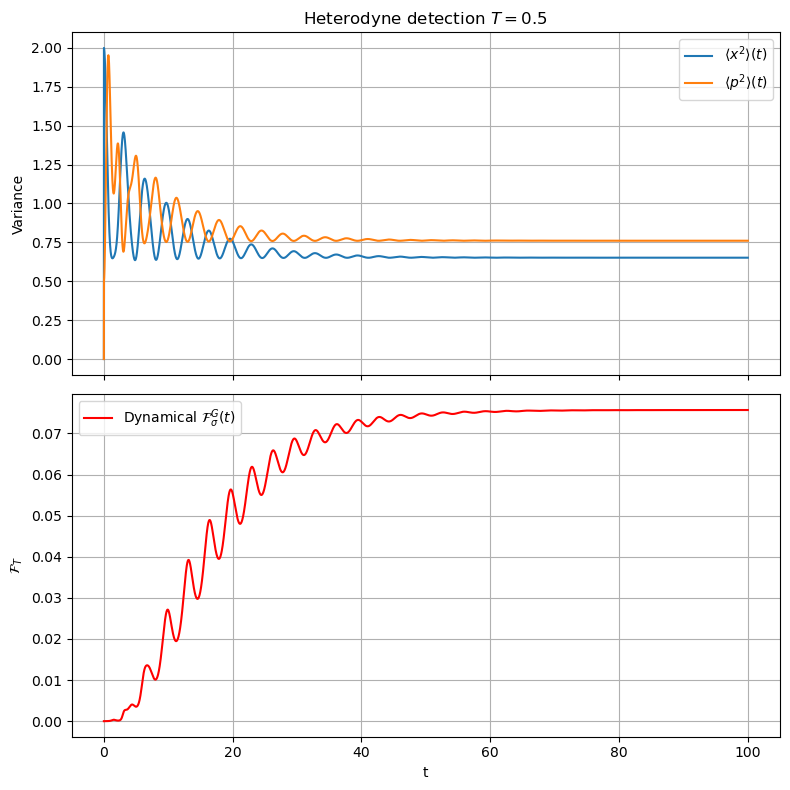

In [4]:
def evolve_FI_dynamics(t_array,x0, p0, sigma0, sigma_M, alpha1, alpha2, Temp, gamma, G, Gdot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real

    x_mean = Gdot_r * x0 + (G_r / mass) * p0
    p_mean = mass * Gddot_r * x0 + Gdot_r * p0
    # System contribution to Covariance (Constant T-derivative = 0)
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    fisher_info_t = np.zeros(N)
    var_x_total = np.zeros(N)
    var_p_total = np.zeros(N)
    
    for i in tqdm(range(1, N), desc="Simulating Dynamics & FI"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        # Standard Covariance Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        var_x_total[i] = sigma_t[0, 0]
        var_p_total[i] = sigma_t[1, 1]
        
        # Derivative Covariance Integrals (Toeplitz)
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # Calculate Fisher Information Term
        inverse_term = np.linalg.inv(sigma_t + sigma_M)
        matrix_prod = np.dot(inverse_term, dsigma_t)
        fisher_info_t[i] = 0.5 * np.trace(np.dot(matrix_prod, matrix_prod))
            
    return {"time": t_array, "x_mean": x_mean, "var_x": var_x_total, "p_mean": p_mean, "var_p": var_p_total, "FI": fisher_info_t}


# ==========================================
# 4. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # --- Physical Parameters (Replace with your actual values) ---
    gamma = 1.0
    alpha1 = 1.0
    alpha2 = 10.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    temp = 0.5
    mass = 1.0
    
    # Simulation Time Grid
    times = np.linspace(0, 100, 10000)
    
    # Laplace Polynomials for the Green's Function
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    # Extract Green's Function and Derivative
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])

    # evaluate inverse Laplace
    Gdot = Gprime_of_t
    
    x0 = 1.0
    p0 = 0.0
    
    sigma0 = np.array([[2.0 / Omega_S_bare, 0], 
                       [0, Omega_S_bare / 2.0]])
    
    # ---------------------------------------------------------
    # DEFINE YOUR MEASUREMENT NOISE MATRIX HERE
    # Example 1: Homodyne (x-quadrature measurement) 
    sigma_M = np.array([[1e6, 0.0], [0.0, 0.0]])  # Large noise on p
    # Example 2: Heterodyne (symmetric measurement)
    #sigma_M = np.array([[0.5, 0.0], [0.0, 0.5]])
    # ---------------------------------------------------------

    # Run Simulation
    # Run Simulation
    sol = evolve_FI_dynamics(times,x0, p0, sigma0, sigma_M, alpha1, alpha2, temp, gamma, G, Gdot, mass)

   # ==========================================
    # 5. PLOT RESULTS WITH ASYMPTOTES
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
    
    # Calculate asymptotic thermal values (High-T limit, Omega_S = 1)
    thermal_variance = temp  
    thermal_FI = 1.0 / (temp + 0.5)**2  # Valid for Heterodyne detection

    # Variance Plot (ax1)
    ax1.plot(sol["time"], sol["var_x"], label=r"$\langle x^2 \rangle(t)$")
    ax1.plot(sol["time"], sol["var_p"], label=r"$\langle p^2 \rangle(t)$")
    
    ax1.set_ylabel("Variance")
    ax1.legend()
    ax1.grid(True)
    ax1.set_title(rf"Heterodyne detection $T={temp}$")
    
    # Fisher Information Plot (ax2)
    ax2.plot(sol["time"], sol["FI"], color='red', label=r"Dynamical $\mathcal{F}_\sigma^G(t)$")
    
    if temp > 19:
        ax1.axhline(thermal_variance, color='black', linestyle='--', alpha=0.7, label=rf"Thermal Asymptote ($T={temp}$)")
        ax2.axhline(thermal_FI, color='black', linestyle='--', alpha=0.7, label=r"Thermal Asymptote $\mathcal{F}_{th}$")
    
    ax2.set_xlabel("t")
    ax2.set_ylabel(r"$\mathcal{F}_T$")
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# Dynamical QFI (T,r)


--- Simulating for T = 0.01 ---


Simulating Dynamics & FI: 100%|██████████| 4999/4999 [00:18<00:00, 273.65it/s]



--- Simulating for T = 1.0 ---


Simulating Dynamics & FI: 100%|██████████| 4999/4999 [00:17<00:00, 291.21it/s]


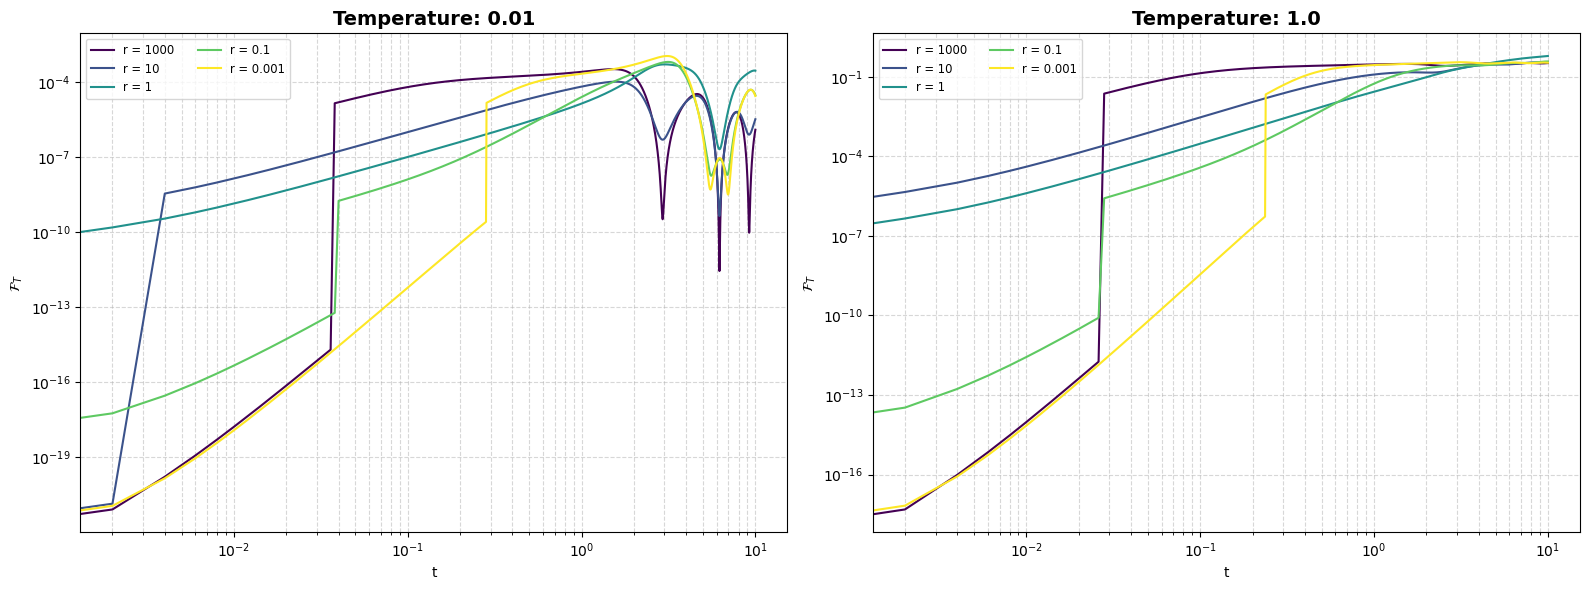

In [ ]:
def generate_sigma0(r, theta):
    """
    Generates the rotated squeezed covariance matrix.
    r: squeezing magnitude (r < 1 position squeezed, r > 1 momentum squeezed)
    theta: squeezing angle in radians
    """
    # Base squeezed state (diagonal)
    sigma_base = 0.5 * np.array([[r, 0], 
                                 [0, 1.0/r]])
    
    # Rotation matrix
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, s], 
                  [-s, c]])
    
    # Apply rotation: R * sigma_base * R^T
    sigma0 = R @ sigma_base @ R.T
    return sigma0


def evolve_FI_dynamics(t_array,x0, p0, sigma0, sigma_M, alpha1, alpha2, Temp, gamma, G, Gdot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real


    x_mean = Gdot_r * x0 + (G_r / mass) * p0
    p_mean = mass * Gddot_r * x0 + Gdot_r * p0
    # System contribution to Covariance (Constant T-derivative = 0)
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    fisher_info_t = np.zeros(N)
    var_x_total = np.zeros(N)
    var_p_total = np.zeros(N)
    QFI = np.zeros(N)
    
    for i in tqdm(range(1, N), desc="Simulating Dynamics & FI"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        # Standard Covariance Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        var_x_total[i] = sigma_t[0, 0]
        var_p_total[i] = sigma_t[1, 1]
        
        # Derivative Covariance Integrals (Toeplitz)
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # Calculate Fisher Information Term
        inverse_term = np.linalg.inv(sigma_t + sigma_M)
        matrix_prod = np.dot(inverse_term, dsigma_t)
        fisher_info_t[i] = 0.5 * np.trace(np.dot(matrix_prod, matrix_prod))

        # --- 3. Quantum FI (Using Analytical Formula from Appendix A) ---
        det_sigma = sigma_t[0,0]*sigma_t[1,1] - sigma_t[0,1]**2
        det_dsigma = dsigma_t[0,0]*dsigma_t[1,1] - dsigma_t[0,1]**2
        d_det_sigma = dsigma_t[0,0]*sigma_t[1,1] + sigma_t[0,0]*dsigma_t[1,1] - 2*sigma_t[0,1]*dsigma_t[0,1]
        
        epsilon = 1e-16 
        purity_term = np.maximum(det_sigma - 0.25, epsilon)
        
        term1 = 0.5 * (d_det_sigma**2) / (purity_term * (det_sigma + 0.25))
        term2 = det_dsigma / (det_sigma + 0.25)
        
        QFI[i] = term1 - term2
            
    return {"time": t_array, "var_x": var_x_total, "var_p": var_p_total, "FI": fisher_info_t, "QFI": QFI}


# ==========================================
# 4. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # --- Physical Parameters ---
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 2.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    mass = 1.0
    
    # Simulation Time Grid
    times = np.linspace(0, 10, 5000)
    
    # Laplace Polynomials for the Green's Function
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    # Extract Green's Function and Derivative
    # (Assuming inverse_laplace_rational and derivatives_from_residues are defined)
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])

    # evaluate inverse Laplace
    Gdot = Gprime_of_t
    
    x0 = 0.0
    p0 = 0.0

    # Measurement Noise Matrix
    sigma_M = np.array([[1/2, 0.0], [0.0, 1/2]]) 

    # ==========================================
    # 5. LOOP OVER TEMPERATURES & R VALUES
    # ==========================================
    temperaturas = [ 0.01, 1.0]
    r_values = [10**3, 10, 1, 0.1, 10**-3]
    theta = 0.0
    
    # Generate colors for the 5 different r values
    import matplotlib.cm as cm
    colores_r = cm.viridis(np.linspace(0, 1, len(r_values)))
    
    # Create a 2x2 grid of subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes = axes.flatten() # Flatten to loop over them easily

    for i, temp in enumerate(temperaturas):
        ax = axes[i]
        print(f"\n--- Simulating for T = {temp} ---")
        
        
        # Loop through initial state squeezing parameters
        for r, color in zip(r_values, colores_r):
            # Generate new initial state for this r
            sigma0 = generate_sigma0(r, theta)
            
            # Run Simulation
            sol = evolve_FI_dynamics(times, x0, p0, sigma0, sigma_M, alpha1, alpha2, temp, gamma, G, Gdot, mass)

            # Plot QFI for this r value
            ax.plot(sol["time"], sol["QFI"], color=color, label=f"r = {r}")

        # Formatting each subplot
        ax.set_title(f"Temperature: {temp}", fontsize=14, fontweight='bold')
        ax.set_xlabel("t")
        ax.set_ylabel(r"$\mathcal{F}_T$")
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.grid(True, which="both", ls="--", alpha=0.5)
        
        # Put a legend inside each plot to keep them self-contained
        ax.legend(loc='best', fontsize='small', ncol=2)

    plt.tight_layout()
    plt.show()

# Dynamical CFI (T, r)


 GENERATING PLOTS FOR: Heterodyne
--- Simulating for T = 0.0001 ---


Simulating Dynamics & FI: 100%|██████████| 999/999 [00:01<00:00, 838.57it/s] 
C:\Users\usuario\AppData\Local\Temp\ipykernel_10008\4222867459.py:200: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 100)


--- Simulating for T = 0.01 ---


Simulating Dynamics & FI: 100%|██████████| 999/999 [00:00<00:00, 1206.74it/s]


--- Simulating for T = 1.0 ---


Simulating Dynamics & FI: 100%|██████████| 999/999 [00:01<00:00, 969.13it/s] 


--- Simulating for T = 5.0 ---


Simulating Dynamics & FI: 100%|██████████| 999/999 [00:00<00:00, 1189.27it/s]


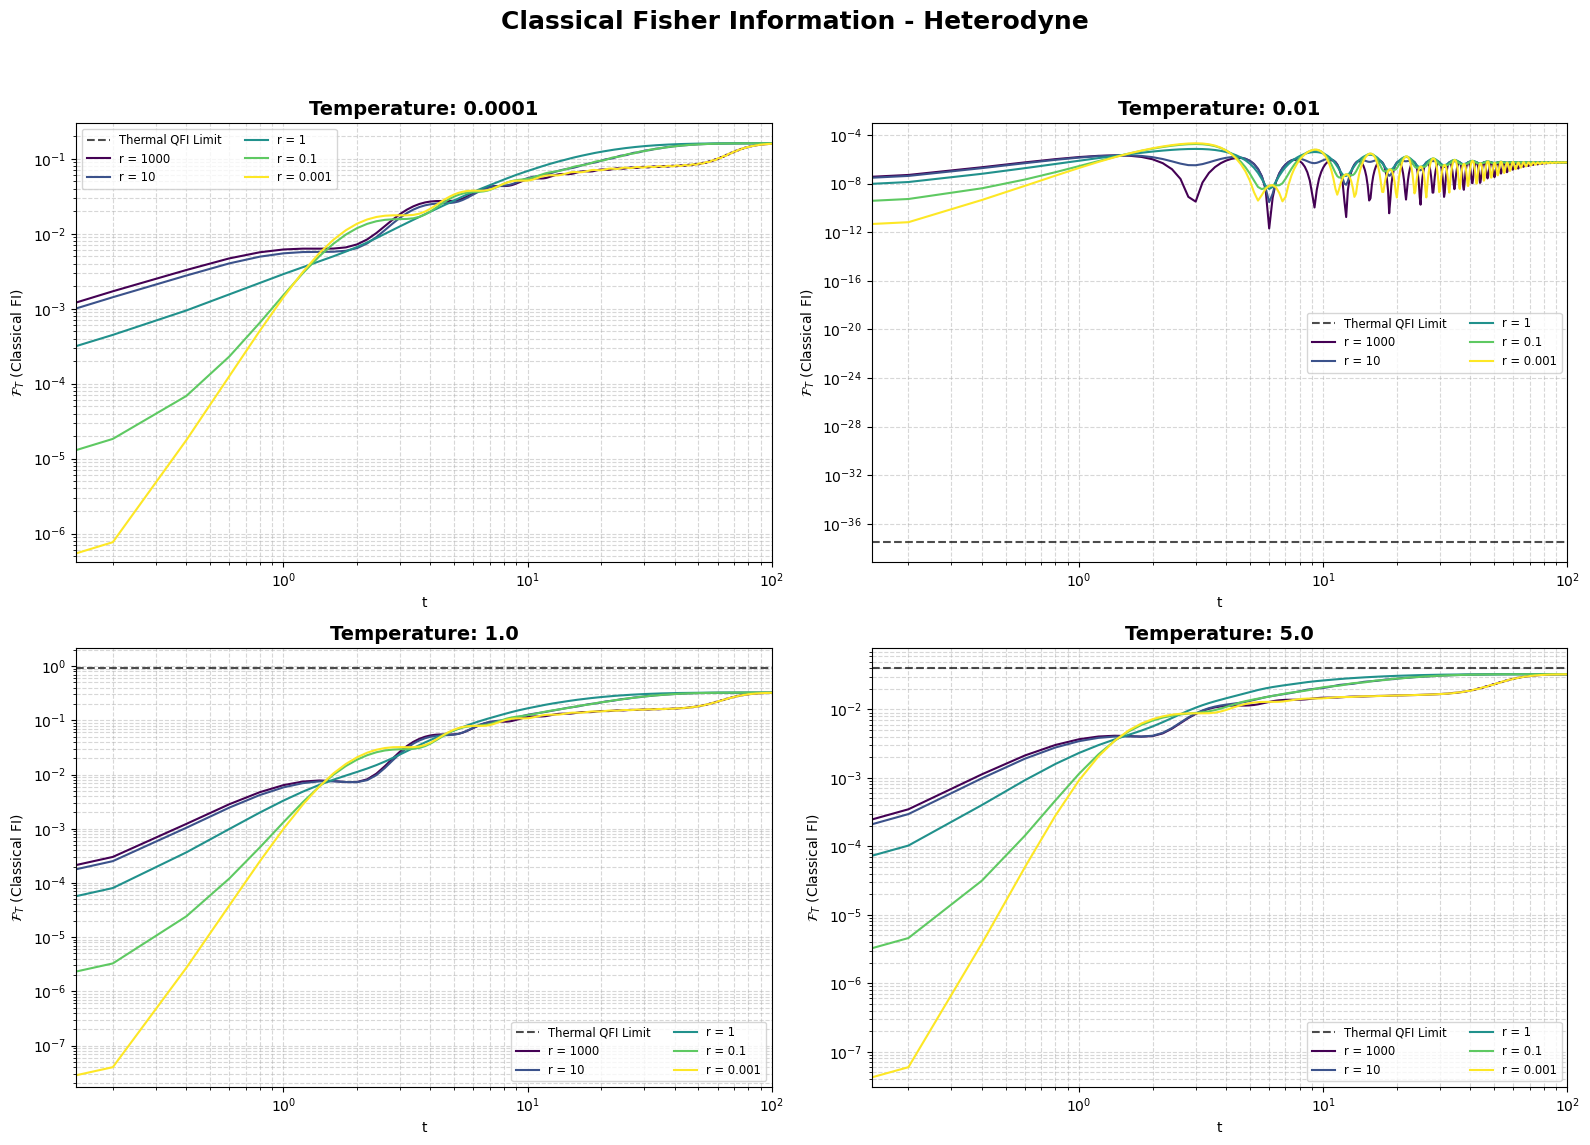


 GENERATING PLOTS FOR: Homodyne X
--- Simulating for T = 0.0001 ---


Simulating Dynamics & FI: 100%|██████████| 999/999 [00:01<00:00, 823.95it/s] 


--- Simulating for T = 0.01 ---


Simulating Dynamics & FI: 100%|██████████| 999/999 [00:01<00:00, 966.88it/s] 


--- Simulating for T = 1.0 ---


Simulating Dynamics & FI: 100%|██████████| 999/999 [00:00<00:00, 1126.70it/s]


--- Simulating for T = 5.0 ---


Simulating Dynamics & FI: 100%|██████████| 999/999 [00:00<00:00, 1156.22it/s]


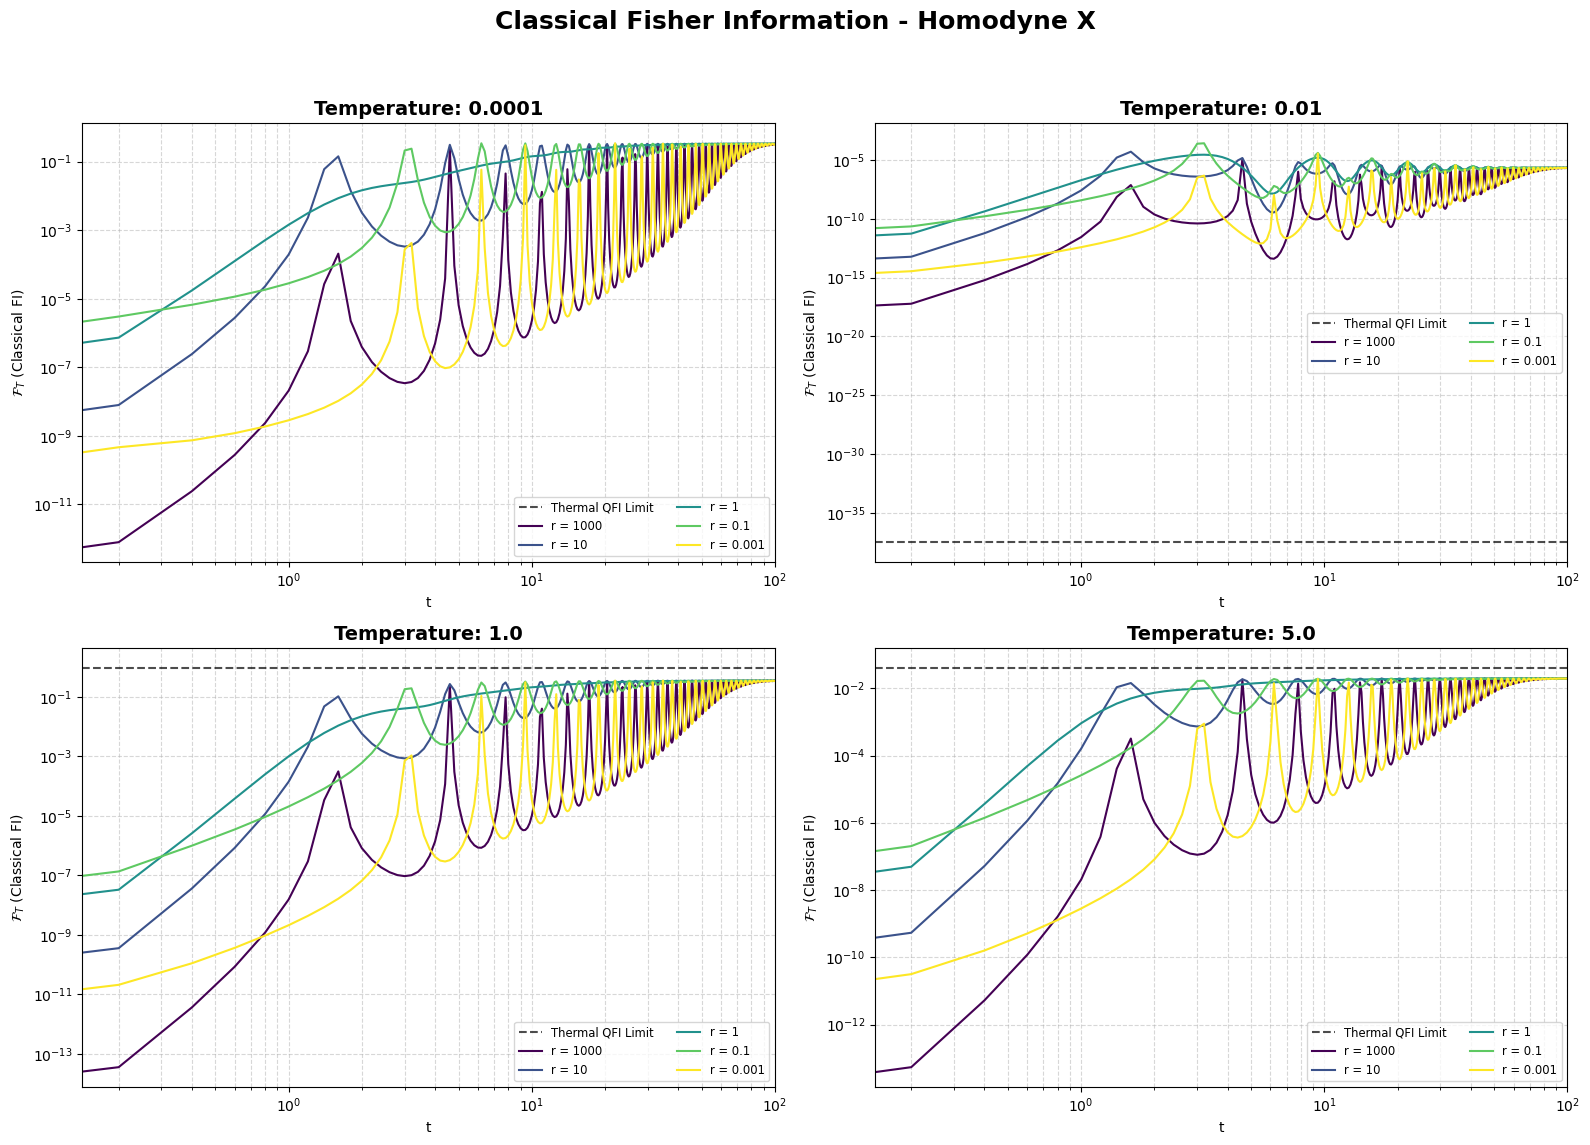


 GENERATING PLOTS FOR: Homodyne P
--- Simulating for T = 0.0001 ---


Simulating Dynamics & FI: 100%|██████████| 999/999 [00:01<00:00, 951.38it/s] 


--- Simulating for T = 0.01 ---


Simulating Dynamics & FI: 100%|██████████| 999/999 [00:01<00:00, 961.01it/s] 


--- Simulating for T = 1.0 ---


Simulating Dynamics & FI: 100%|██████████| 999/999 [00:01<00:00, 724.20it/s]


--- Simulating for T = 5.0 ---


Simulating Dynamics & FI: 100%|██████████| 999/999 [00:01<00:00, 922.69it/s] 


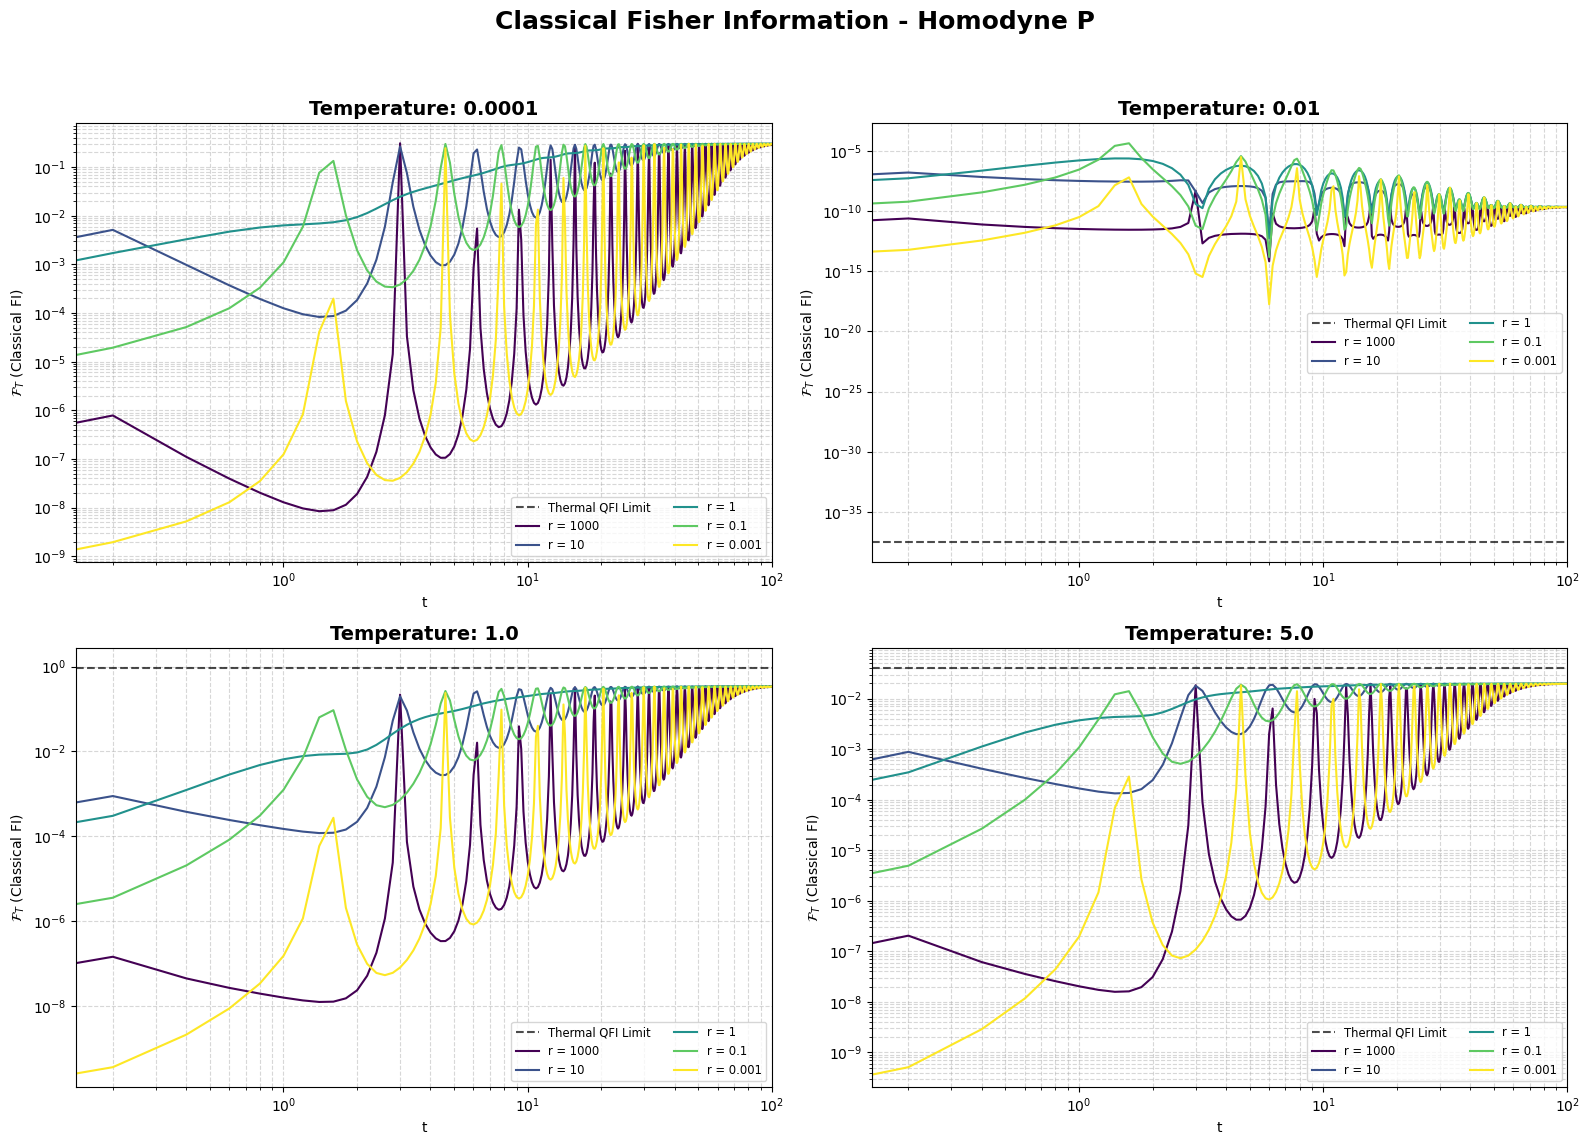

In [ ]:
def generate_sigma0(r, theta):
    """
    Generates the rotated squeezed covariance matrix.
    r: squeezing magnitude (r < 1 position squeezed, r > 1 momentum squeezed)
    theta: squeezing angle in radians
    """
    # Base squeezed state (diagonal)
    sigma_base = 0.5 * np.array([[r, 0], 
                                 [0, 1.0/r]])
    
    # Rotation matrix
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, s], 
                  [-s, c]])
    
    # Apply rotation: R * sigma_base * R^T
    sigma0 = R @ sigma_base @ R.T
    return sigma0


def evolve_FI_dynamics(t_array,x0, p0, sigma0, sigma_M, alpha1, alpha2, Temp, gamma, G, Gdot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real


    x_mean = Gdot_r * x0 + (G_r / mass) * p0
    p_mean = mass * Gddot_r * x0 + Gdot_r * p0
    # System contribution to Covariance (Constant T-derivative = 0)
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    fisher_info_t = np.zeros(N)
    var_x_total = np.zeros(N)
    var_p_total = np.zeros(N)
    QFI = np.zeros(N)
    
    for i in tqdm(range(1, N), desc="Simulating Dynamics & FI"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        # Standard Covariance Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        var_x_total[i] = sigma_t[0, 0]
        var_p_total[i] = sigma_t[1, 1]
        
        # Derivative Covariance Integrals (Toeplitz)
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # Calculate Fisher Information Term
        inverse_term = np.linalg.inv(sigma_t + sigma_M)
        matrix_prod = np.dot(inverse_term, dsigma_t)
        fisher_info_t[i] = 0.5 * np.trace(np.dot(matrix_prod, matrix_prod))

        # --- 3. Quantum FI (Using Analytical Formula from Appendix A) ---
        det_sigma = sigma_t[0,0]*sigma_t[1,1] - sigma_t[0,1]**2
        det_dsigma = dsigma_t[0,0]*dsigma_t[1,1] - dsigma_t[0,1]**2
        d_det_sigma = dsigma_t[0,0]*sigma_t[1,1] + sigma_t[0,0]*dsigma_t[1,1] - 2*sigma_t[0,1]*dsigma_t[0,1]
        
        epsilon = 1e-16 
        purity_term = np.maximum(det_sigma - 0.25, epsilon)
        
        term1 = 0.5 * (d_det_sigma**2) / (purity_term * (det_sigma + 0.25))
        term2 = det_dsigma / (det_sigma + 0.25)
        
        QFI[i] = term1 - term2
            
    return {"time": t_array, "var_x": var_x_total, "var_p": var_p_total, "FI": fisher_info_t, "QFI": QFI}


# ==========================================
# 4. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # --- Physical Parameters ---
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 2.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    mass = 1.0
    
    # Simulation Time Grid
    times = np.linspace(0, 200, 1000)
    
    # Laplace Polynomials for the Green's Function
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    # Extract Green's Function and Derivative
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
    Gdot = Gprime_of_t
    
    x0 = 1.0
    p0 = 0.0

    # Temperatures and Squeezing Parameters
    temperaturas = [0.0001, 0.01, 1.0, 5.0]
    r_values = [10**3, 10, 1, 0.1, 10**-3]
    theta = 0.0
    
    import matplotlib.cm as cm
    colores_r = cm.viridis(np.linspace(0, 1, len(r_values)))

    # ---------------------------------------------------------
    # DEFINE GAUSSIAN MEASUREMENTS
    # ---------------------------------------------------------
    # Homodyne X measures x perfectly (infinite noise added to p)
    # Homodyne P measures p perfectly (infinite noise added to x)
    measurements = {
        "Heterodyne": np.array([[0.5, 0.0], [0.0, 0.5]]),
        "Homodyne X": np.array([[0.0, 0.0], [0.0, 1e8]]), 
        "Homodyne P": np.array([[1e8, 0.0], [0.0, 0.0]])
    }

    # ==========================================
    # 5. LOOP OVER MEASUREMENTS, TEMPERATURES & R
    # ==========================================
    for meas_name, sigma_M in measurements.items():
        print(f"\n========================================")
        print(f" GENERATING PLOTS FOR: {meas_name}")
        print(f"========================================")
        
        # Create a new figure for each measurement scheme
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(f"Classical Fisher Information - {meas_name}", fontsize=18, fontweight='bold')
        axes = axes.flatten()

        for i, temp in enumerate(temperaturas):
            ax = axes[i]
            print(f"--- Simulating for T = {temp} ---")
            
            # Thermal Asymptote (Valid for HO at weak coupling)
            #thermal_QFI = 0.25 * (Omega_S**2 / temp**4) * csch2(Omega_S / (2 * temp)) 
            
            # Plot the Thermal QFI Asymptote as an upper bound reference
            #ax.axhline(thermal_QFI, color='black', linestyle='--', alpha=0.7, label=f"Thermal QFI Limit")
            
            # Loop through initial state squeezing parameters
            for r, color in zip(r_values, colores_r):
                sigma0 = generate_sigma0(r, theta)
                
                # Run Simulation
                sol = evolve_FI_dynamics(times, x0, p0, sigma0, sigma_M, alpha1, alpha2, temp, gamma, G, Gdot, mass)

                # Plot CLASSICAL FI for this measurement scheme
                ax.plot(sol["time"], sol["FI"], color=color, label=f"r = {r}")

            # Formatting each subplot
            ax.set_title(f"Temperature: {temp}", fontsize=14, fontweight='bold')
            ax.set_xlabel("t")
            ax.set_ylabel(r"$\mathcal{F}_T$ (Classical FI)")
            ax.set_yscale('log')
            ax.set_xscale('log')
            ax.set_xlim(0, 100)
            ax.grid(True, which="both", ls="--", alpha=0.5)
            
            ax.legend(loc='best', fontsize='small', ncol=2)

        # Adjust layout so the suptitle doesn't overlap with the plots
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# Dynamical QFI alternative check


--- Simulando para T = 0.05 ---


Simulating Dynamics & FI: 100%|██████████| 799/799 [00:01<00:00, 626.76it/s]


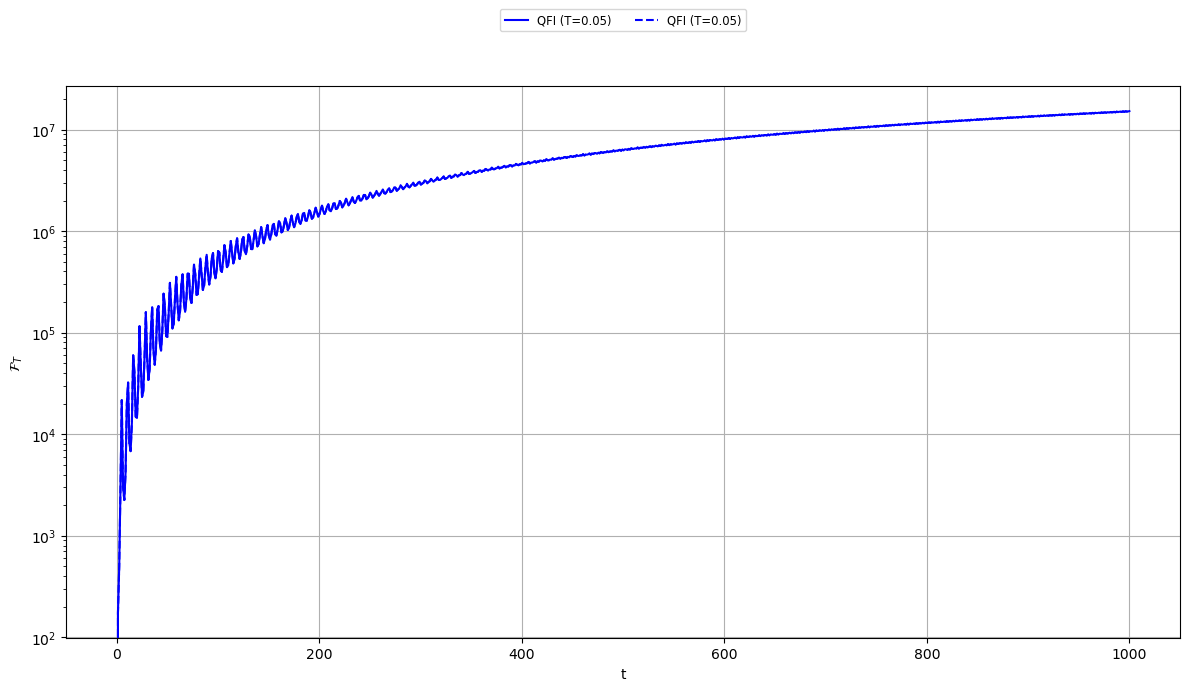

In [26]:
import numpy as np
from tqdm import tqdm

def evolve_FI_dynamics(t_array, x0, p0, sigma0, sigma_M, alpha1, alpha2, Temp, gamma, G, Gdot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real

    x_mean = Gdot_r * x0 + (G_r / mass) * p0
    p_mean = mass * Gddot_r * x0 + Gdot_r * p0
    
    # System contribution to Covariance (Constant T-derivative = 0)
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    fisher_info_t = np.zeros(N)
    var_x_total = np.zeros(N)
    var_p_total = np.zeros(N)
    QFI = np.zeros(N)
    QFI_alternative = np.zeros(N)  # New array for analytical QFI

    #QFI
    Omega_symp = np.array([[0, 1], [-1, 0]])
    kron_omega = np.kron(Omega_symp, Omega_symp)
    
    for i in tqdm(range(1, N), desc="Simulating Dynamics & FI"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        # Standard Covariance Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        var_x_total[i] = sigma_t[0, 0]
        var_p_total[i] = sigma_t[1, 1]
        
        # Derivative Covariance Integrals (Toeplitz)
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # Calculate Fisher Information Term
        inverse_term = np.linalg.inv(sigma_t + sigma_M)
        matrix_prod = np.dot(inverse_term, dsigma_t)
        fisher_info_t[i] = 0.5 * np.trace(np.dot(matrix_prod, matrix_prod))

        # --- ORIGINAL KRONECKER QFI CALCULATION ---
        kron_sigma = np.kron(sigma_t, sigma_t)
        M = kron_sigma - 0.25*kron_omega
        
        evals, evecs = np.linalg.eigh(M)
        threshold = 1e-7
        evals_inv = np.where(evals > threshold, 1.0 / evals, 0.0)
        M_inv = evecs @ np.diag(evals_inv) @ evecs.T
        
        dsigma_vec = dsigma_t.flatten(order='F') 
        QFI[i] = 0.5 * np.dot(dsigma_vec.T, np.dot(M_inv, dsigma_vec))
        
        # --- NEW ALTERNATIVE ANALYTICAL QFI ---
        # 1. Determinants of sigma and dsigma
        det_sigma = sigma_t[0, 0] * sigma_t[1, 1] - sigma_t[0, 1] * sigma_t[1, 0]
        det_dsigma = dsigma_t[0, 0] * dsigma_t[1, 1] - dsigma_t[0, 1] * dsigma_t[1, 0]
        
        # 2. Derivative of the determinant: d(det(sigma))/dtheta
        d_det_sigma = (dsigma_t[0, 0] * sigma_t[1, 1] + 
                       sigma_t[0, 0] * dsigma_t[1, 1] - 
                       2 * sigma_t[0, 1] * dsigma_t[0, 1])
        
        # 3. Safeguard for pure states (det_sigma -> 0.25) to prevent division by zero
        purity_diff = max(det_sigma - 0.25, 1e-12)
        
        # 4. Construct the two terms of your equation
        term1 = 0.5 * (d_det_sigma**2) / (purity_diff * (det_sigma + 0.25))
        term2 = det_dsigma / (det_sigma + 0.25)
        
        QFI_alternative[i] = term1 - term2
            
    return {
        "time": t_array, 
        "var_x": var_x_total, 
        "var_p": var_p_total, 
        "FI": fisher_info_t, 
        "QFI": QFI, 
        "QFI_alternative": QFI_alternative
    }

if __name__ == "__main__":
    # --- Physical Parameters (Replace with your actual values) ---
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 0.01
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    mass = 1.0
    
    # Simulation Time Grid
    times = np.linspace(0, 1000, 800)
    
    # Laplace Polynomials for the Green's Function
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    # Extract Green's Function and Derivative
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])

    # evaluate inverse Laplace
    Gdot = Gprime_of_t
    
    x0 = 1.0
    p0 = 0.0

    sigma0 = np.array([[1/(2*Omega_S_bare), 0], 
                       [0, Omega_S_bare/2]])
    
    # ---------------------------------------------------------
    # DEFINE YOUR MEASUREMENT NOISE MATRIX HERE
    # Example 1: Homodyne (x-quadrature measurement) 
    sigma_M = np.array([[1/2, 0.0], [0.0, 1/2]])  # Large noise on p
    # Example 2: Heterodyne (symmetric measurement)
    #sigma_M = np.array([[0.5, 0.0], [0.0, 0.5]])
    # ---------------------------------------------------------

    # ==========================================
    # 5. LOOP OVER TEMPERATURES & PLOT RESULTS
    # ==========================================
    temperaturas = [0.05]
    colores = ['blue', 'orange', 'green', 'red']
    
    plt.figure(figsize=(12, 7))

    for temp, color in zip(temperaturas, colores):
        print(f"\n--- Simulando para T = {temp} ---")
        
        # Run Simulation for current temperature
        sol = evolve_FI_dynamics(times, x0, p0, sigma0, sigma_M, alpha1, alpha2, temp, gamma, G, Gdot, mass)

        # Thermal Asymptote (Valid for HO but JUST AT WEAKLY COUPLING!!)
        thermal_QFI = 0.25 * (Omega_S**2 / temp**4) * csch2(Omega_S / (2 * temp)) 
        
        # Plot QFI and its corresponding thermal asymptote
        plt.plot(sol["time"], sol["QFI"], color=color, label=f"QFI (T={temp})")
        plt.plot(sol["time"], sol["QFI_alternative"], linestyle = '--', color=color, label=f"QFI (T={temp})")
        #plt.axhline(thermal_QFI, color=color, linestyle='--', alpha=0.7, label=f"Thermal (T={temp}) - Weak limit")

    # Formatting the plot
    plt.xlabel("t")
    plt.ylabel(r"$\mathcal{F}_T$")
    
    plt.yscale('log')

    # Opcional: Ajustar los límites para que no empiece desde un valor negativo imposible
    # La escala logarítmica no admite valores <= 0, si tu QFI toca el cero, 
    # ajustamos el límite inferior manualmente:
    #plt.xlim(0, 100)

    # Ajustamos la leyenda fuera del gráfico para que no tape las curvas si son muchas
    plt.legend(
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.15), 
    ncol=4, 
    fontsize='small'
    )
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Dynamical CFI and QFI rates


Simulating Dynamics & FIs for T = 0.01...


Simulating Dynamics & FIs: 100%|██████████| 4999/4999 [00:09<00:00, 512.12it/s] 



Simulating Dynamics & FIs for T = 0.1...


Simulating Dynamics & FIs: 100%|██████████| 4999/4999 [00:09<00:00, 531.80it/s] 



Simulating Dynamics & FIs for T = 1...


Simulating Dynamics & FIs: 100%|██████████| 4999/4999 [00:09<00:00, 521.76it/s] 



Simulating Dynamics & FIs for T = 10...


Simulating Dynamics & FIs: 100%|██████████| 4999/4999 [00:09<00:00, 523.35it/s] 


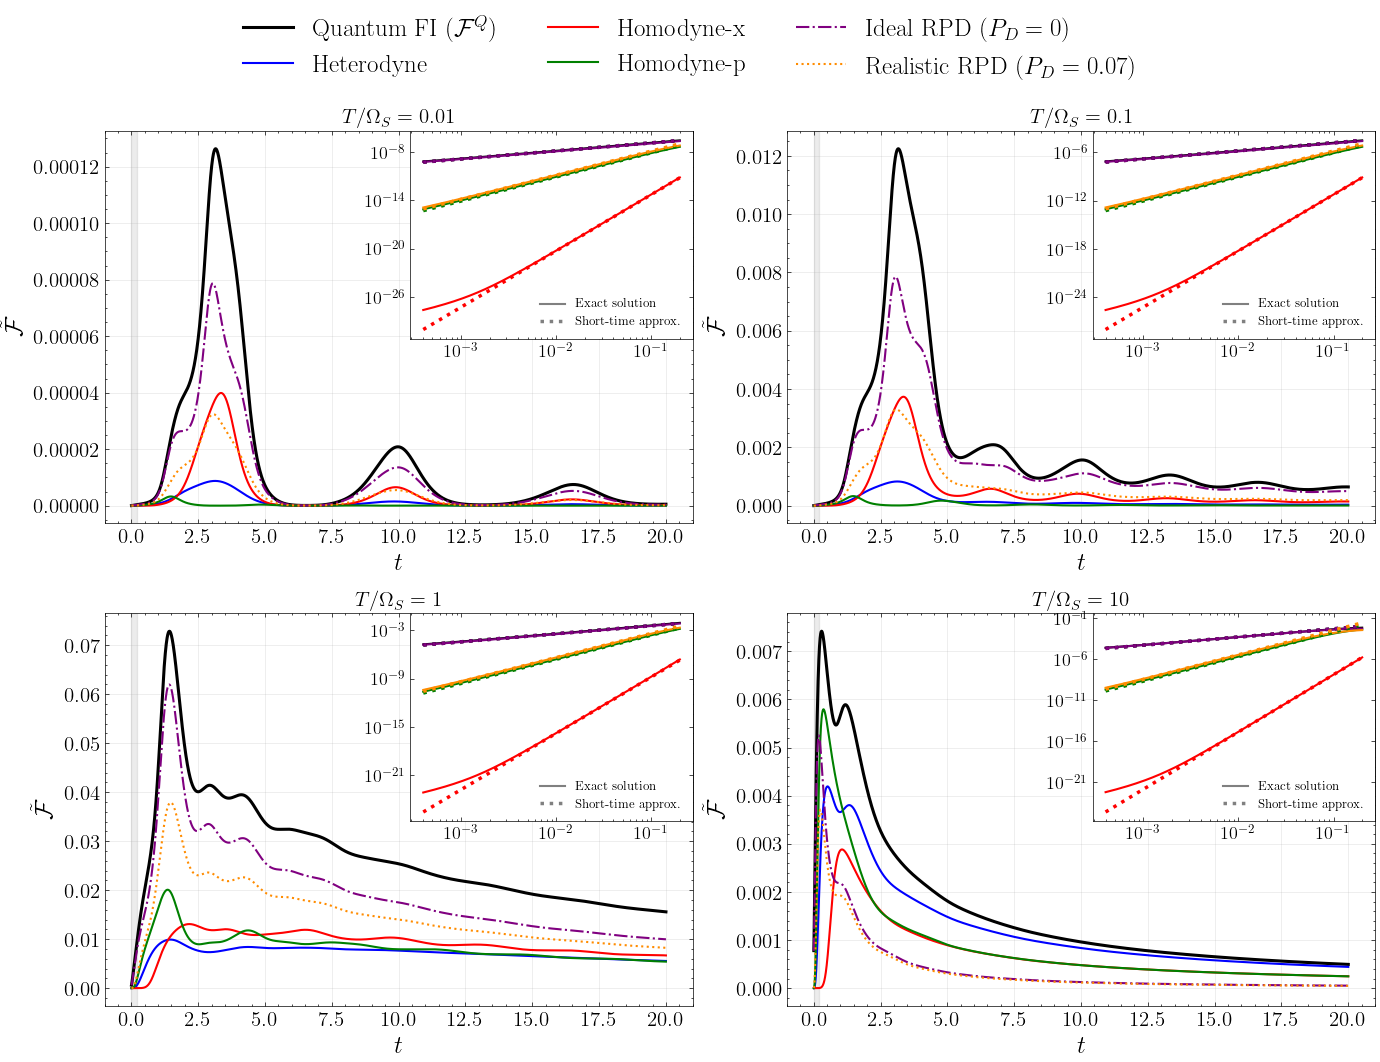

In [10]:
def evolve_all_FI_dynamics(t_array, x0, p0, sigma0, alpha1, alpha2, Temp, gamma, G, Gdot, Gddot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real
    
    # System contribution to Covariance (Constant T-derivative = 0)
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    if not np.all(np.isfinite(nu_grid)):
        raise ValueError("nu_grid contains NaNs or infs")

    if not np.all(np.isfinite(dnu_grid)):
        raise ValueError("dnu_grid contains NaNs or infs")
    
    # Arrays to store tracking variables (add FI_rpd)
    # Arrays to store tracking variables (added FI_rpd_real)
    FI_het, FI_hom_x, FI_hom_p, QFI, FI_rpd, FI_rpd_real, covariance = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    
    # Define Measurement Matrices
    sig_M_het = np.array([[0.5, 0.0], [0.0, 0.5]])
    sig_M_hom_x = np.array([[1e-6, 0.0], [0.0, 1e6]]) # Infinite noise on p
    sig_M_hom_p = np.array([[1e6, 0.0], [0.0, 1e-6]]) # Infinite noise on x

    # Thermal values for the FI
    FI_th_het = 0.5 * ((1/(Temp+sig_M_het[0,0]*Omega_S)**2)+(1/(Temp+sig_M_het[1,1])**2))
    FI_th_hom_x = 0.5 * ((1/(Temp + sig_M_hom_x[0,0]*Omega_S)**2)+(1/(Temp + sig_M_hom_x[1,1])**2))
    FI_th_hom_p = 0.5 * ((1/(Temp + sig_M_hom_p[0,0]*Omega_S)**2)+(1/(Temp + sig_M_hom_p[1,1])**2))

    
    def calc_classical_CFI(sig, dsig, sig_M):
        inv_term = np.linalg.inv(sig + sig_M)
        prod = np.dot(inv_term, dsig)
        return 0.5 * np.trace(np.dot(prod, prod))

    for i in tqdm(range(1, N), desc="Simulating Dynamics & FIs"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        t_current = t_array[i]
        # Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        covariance[i] = cov_xp_sys[i] + cov_xp_bath

        # 1. Classical FIs
        FI_het[i] = (calc_classical_CFI(sigma_t, dsigma_t, sig_M_het))/t_current
        FI_hom_x[i] = (calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_x))/t_current
        FI_hom_p[i] = (calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_p))/t_current
        
        # --- On/Off Photodetection (RPD) FI ---
        A_rpd = sigma_t + sig_M_het
        det_A = np.linalg.det(A_rpd)
        inv_A = np.linalg.inv(A_rpd)
        trace_term = np.trace(np.dot(inv_A, dsigma_t))
        
        # Base vacuum probability without dark counts
        P_0_base = 1.0 / np.sqrt(det_A)
        
        # 1. Ideal RPD (P_D = 0.0)
        dP_0_ideal = -0.5 * P_0_base * trace_term
        FI_rpd[i] = ((dP_0_ideal**2) / (P_0_base * (1.0 - P_0_base) + 1e-15))/t_current
        
        # 2. Realistic RPD (P_D = 0.02)
        P_D_val = 0.07
        P_0_real = (1.0 - P_D_val) * P_0_base
        dP_0_real = -0.5 * P_0_real * trace_term
        FI_rpd_real[i] = ((dP_0_real**2) / (P_0_real * (1.0 - P_0_real) + 1e-15))/t_current
        
        # --- 3. Quantum FI (Using Analytical Formula from Appendix A) ---
        det_sigma = sigma_t[0,0]*sigma_t[1,1] - sigma_t[0,1]**2
        det_dsigma = dsigma_t[0,0]*dsigma_t[1,1] - dsigma_t[0,1]**2
        d_det_sigma = dsigma_t[0,0]*sigma_t[1,1] + sigma_t[0,0]*dsigma_t[1,1] - 2*sigma_t[0,1]*dsigma_t[0,1]
        
        epsilon = 1e-16 
        purity_term = np.maximum(det_sigma - 0.25, epsilon)
        
        term1 = 0.5 * (d_det_sigma**2) / (purity_term * (det_sigma + 0.25))
        term2 = det_dsigma / (det_sigma + 0.25)
        
        QFI[i] = (term1 - term2)/t_current
        
    return {
        "time": t_array, 
        "FI_het": FI_het, 
        "FI_hom_x": FI_hom_x, 
        "FI_hom_p": FI_hom_p, 
        "FI_rpd": FI_rpd,
        "FI_rpd_real": FI_rpd_real,  # <-- Add this line
        "QFI": QFI, 
        "FI_th_het": FI_th_het, 
        "FI_th_hom_x": FI_th_hom_x, 
        "FI_th_hom_p": FI_th_hom_p,
        "covariance" : covariance
    }


# ==========================================
# 4. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # --- Physical Parameters ---
    gamma = 1.0
    alpha1 = 1
    alpha2 = 10.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    mass = 1.0
    
    # Simulation Time Grid
    # Simulation Time Grid (Main)
    times = np.linspace(0, 20, 5000)
    
    # --- NUEVO: Simulation Time Grid (Short for Inset) ---
    times_short = np.linspace(0, 0.2, 5000) 

    # Laplace Polynomials for Green's Function
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    # Extract Green's Function (Main)
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
    Gdot = Gprime_of_t
    
    # --- NUEVO: Extract Green's Function (Short) ---
    G_short, Gprime_short, Gddot_short = derivatives_from_residues(times_short, info["residues"], info["poles"])
    Gdot_short = Gprime_short
    
    # Initial State Covariance Matrix (Fixed grouping bug)
    x0 = 0.0
    p0 = 0.0
    sigma0 = np.array([[1.0 / (2.0 * Omega_S_bare), 0.0], 
                       [0.0, Omega_S_bare / 2.0]])

    # List of temperatures to plot
    temperatures = [0.01, 0.1, 1, 10]
    #temperatures = [30]
    
    # --- Setup 2x2 Subplot Grid ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()  # Flatten 2D array to 1D for easy iteration

    
    for ax, temp in zip(axes, temperatures):
        print(f"\nSimulating Dynamics & FIs for T = {temp}...")
        
        # Thermal QFI for a single HO
        QFI_th_HO = 0.25 * (Omega_S**2 / temp**4) * csch2(Omega_S / (2.0 * temp))
        
        # 1. Run Dynamic Simulation
        sol = evolve_all_FI_dynamics(times, x0, p0, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, Gddot, mass)
        
        # 2. Plot Dynamical Curves
        ax.plot(sol["time"][1:], sol["QFI"][1:], color='black', linewidth=2.2, label=r"Quantum FI ($\mathcal{F}^Q$)")
        ax.plot(sol["time"][1:], sol["FI_het"][1:], color='blue', linewidth=1.5, label="Heterodyne")
        ax.plot(sol["time"][1:], sol["FI_hom_x"][1:], color='red', linewidth=1.5, label="Homodyne-x")
        ax.plot(sol["time"][1:], sol["FI_hom_p"][1:], color='green', linewidth=1.5, label="Homodyne-p")
        ax.plot(sol["time"][1:], sol["FI_rpd"][1:], color='purple', linewidth=1.5, linestyle='-.', label="Ideal RPD ($P_D=0$)")
        ax.plot(sol["time"][1:], sol["FI_rpd_real"][1:], color='darkorange', linewidth=1.5, linestyle=':', label="Realistic RPD ($P_D=0.07$)")
        
        # 4. Subplot Formatting
        ax.set_title(rf"$T/\Omega_S = {temp}$", fontsize=15)
        ax.set_xlabel(r"$t$")
        ax.set_ylabel(r"$\tilde{\mathcal{F}}$")
        ax.grid(True, alpha=0.3)
        #ax.legend(loc='best', fontsize=8)
        #ax.set_xlim(1e-1,10)
        #ax.set_xscale('log')


        # --- 3. Short-Time Inset (Alta Resolución) ---
        inset_ax = ax.inset_axes([0.52, 0.47, 0.48, 0.53]) 

        sol_short = evolve_all_FI_dynamics(times_short, x0, p0, sigma0, alpha1, alpha2, temp, gamma, G_short, Gdot_short, Gddot_short, mass)

        # 1. SALTAMOS los primeros 50 puntos para evitar el ruido numérico en t~0
        skip = 10
        t_s = times_short[skip:] 

        # Calculate noise kernel parameters at time zero
        nu_0 = noise_kernel_residue(0.0, gamma, alpha1, alpha2, temp) / mass
        dnu_0 = dnu_dT_residue(0.0, gamma, alpha1, alpha2, temp) / mass

        x2_0 = sigma0[0, 0]
        a_0 = sigma0[0, 0] 
        b_0 = sigma0[1, 1]
        P_D = 0.07

        # Analytical Rates
        qfi_analyt = x2_0 * (dnu_0**2 / nu_0) * t_s
        hom_x_analyt = (dnu_0**2 / (32 * a_0**2)) * t_s**7
        hom_p_analyt = (dnu_0**2 / (2 * b_0**2)) * t_s**3
        rpd_ideal_analyt = 0.5 * (dnu_0**2 / nu_0) * t_s
        rpd_real_analyt = ((1 - P_D) * dnu_0**2 / (4 * P_D)) * t_s**3

        # 2. Aplicamos el 'skip' a los datos exactos también
        inset_ax.plot(t_s, sol_short["QFI"][skip:], color='black', linewidth=1.5)
        inset_ax.plot(t_s, sol_short["FI_hom_x"][skip:], color='red', linewidth=1.5)
        inset_ax.plot(t_s, sol_short["FI_hom_p"][skip:], color='green', linewidth=1.5)
        inset_ax.plot(t_s, sol_short["FI_rpd"][skip:], color='purple', linewidth=1.5)
        inset_ax.plot(t_s, sol_short["FI_rpd_real"][skip:], color='darkorange', linewidth=1.5)

        # Plot analytical approximations
        inset_ax.plot(t_s, qfi_analyt, color='black', linestyle=':', linewidth=2.5)
        inset_ax.plot(t_s, hom_x_analyt, color='red', linestyle=':', linewidth=2.5)
        inset_ax.plot(t_s, hom_p_analyt, color='green', linestyle=':', linewidth=2.5)
        inset_ax.plot(t_s, rpd_ideal_analyt, color='purple', linestyle=':', linewidth=2.5)
        inset_ax.plot(t_s, rpd_real_analyt, color='darkorange', linestyle=':', linewidth=2.5)

        # Inset formatting 
        inset_ax.set_xscale('log')
        inset_ax.set_yscale('log')
        inset_ax.tick_params(axis='both', which='both', labelsize=13)
        
        
        # Opcional: Descomenta esto para forzar que el plot principal no se deforme
        # ax.set_ylim(0.0, 0.08)

        # --- AÑADIR LEYENDA DE ESTILOS AL INSET ---
        # 1. Creamos líneas vacías con los estilos correspondientes
        inset_ax.plot([], [], color='gray', linestyle='-', linewidth=1.5, label='Exact solution')
        inset_ax.plot([], [], color='gray', linestyle=':', linewidth=2.5, label='Short-time approx.')
        
        # 2. Mostramos la leyenda solo para este inset
        inset_ax.legend(loc='lower right', fontsize=9, frameon=False)
        
        limite_temporal_inset = times_short[-1] 
        
        ax.axvspan(0, limite_temporal_inset, color='gray', alpha=0.15)

    handles, labels = ax.get_legend_handles_labels()

    # Creamos la leyenda global anclada a la Figura (no al subplot)
    # ncol=3 pondrá las 6 curvas en 2 filas muy ordenadas
    fig.legend(handles, labels, 
               loc='upper center', 
               bbox_to_anchor=(0.5, 1.08), 
               ncol=3, 
               fontsize=18, 
               frameon=False) # Quitar el frame suele quedar más elegante en SciencePlots

    # Usamos tight_layout pero reservamos un 10% de espacio arriba (top=0.9) 
    # para que los títulos de los plots no choquen con la leyenda
    plt.tight_layout(rect=[0, 0, 1, 0.98]) 
    
    plt.show()

# QFI Rate (T, r)


--- Simulating for T = 0.01 ---


Simulating Dynamics & FI: 100%|██████████| 4999/4999 [00:19<00:00, 255.36it/s]
C:\Users\usuario\AppData\Local\Temp\ipykernel_15216\2577376914.py:186: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 10)



--- Simulating for T = 1.0 ---


Simulating Dynamics & FI: 100%|██████████| 4999/4999 [00:18<00:00, 266.07it/s]


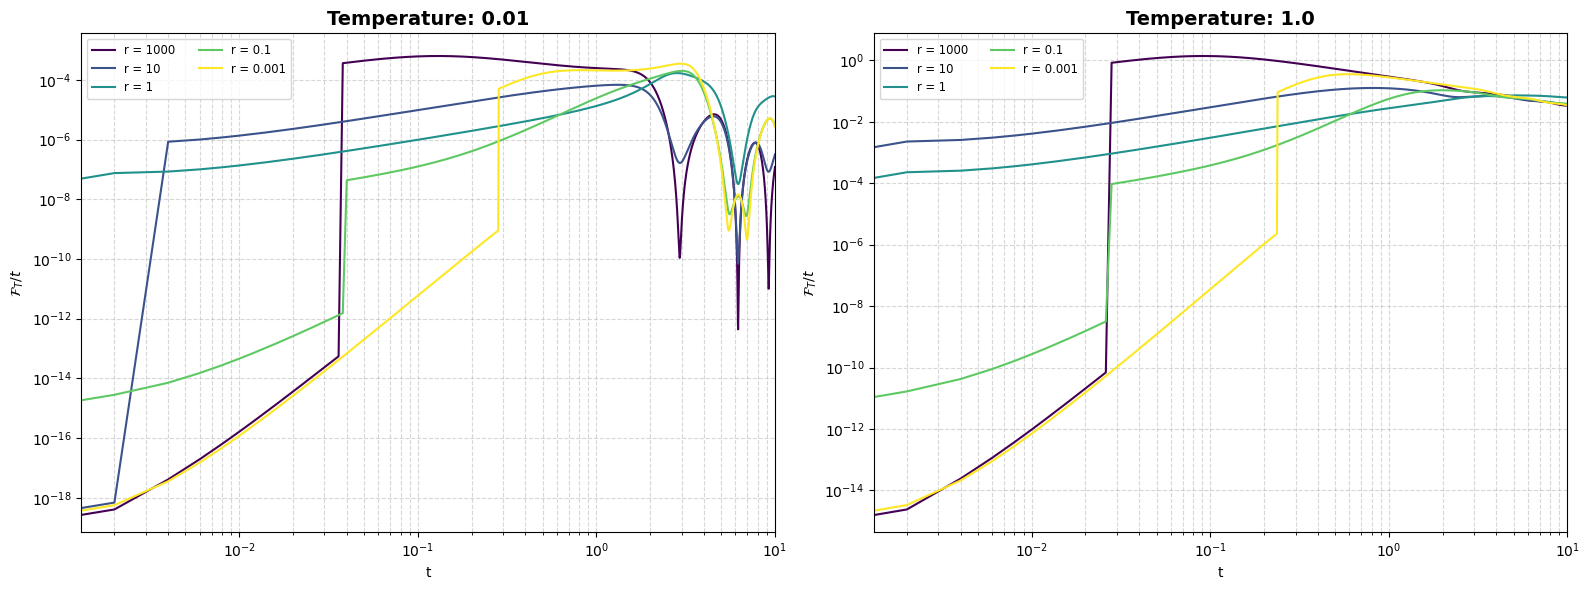

In [ ]:
def generate_sigma0(r, theta):
    """
    Generates the rotated squeezed covariance matrix.
    r: squeezing magnitude (r < 1 position squeezed, r > 1 momentum squeezed)
    theta: squeezing angle in radians
    """
    # Base squeezed state (diagonal)
    sigma_base = 0.5 * np.array([[r, 0], 
                                 [0, 1.0/r]])
    
    # Rotation matrix
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, s], 
                  [-s, c]])
    
    # Apply rotation: R * sigma_base * R^T
    sigma0 = R @ sigma_base @ R.T
    return sigma0


def evolve_FI_dynamics(t_array,x0, p0, sigma0, sigma_M, alpha1, alpha2, Temp, gamma, G, Gdot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real


    x_mean = Gdot_r * x0 + (G_r / mass) * p0
    p_mean = mass * Gddot_r * x0 + Gdot_r * p0
    # System contribution to Covariance (Constant T-derivative = 0)
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    fisher_info_t = np.zeros(N)
    var_x_total = np.zeros(N)
    var_p_total = np.zeros(N)
    QFI = np.zeros(N)

    #QFI
    Omega_symp = np.array([[0, 1], [-1, 0]])
    kron_omega = np.kron(Omega_symp, Omega_symp)
    
    for i in tqdm(range(1, N), desc="Simulating Dynamics & FI"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        t_i = t_array[i]
        
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        # Standard Covariance Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        var_x_total[i] = sigma_t[0, 0]
        var_p_total[i] = sigma_t[1, 1]
        
        # Derivative Covariance Integrals (Toeplitz)
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # Calculate Fisher Information Term
        inverse_term = np.linalg.inv(sigma_t + sigma_M)
        matrix_prod = np.dot(inverse_term, dsigma_t)
        fisher_info_t[i] = 0.5 * np.trace(np.dot(matrix_prod, matrix_prod))

        # --- 3. Quantum FI (Using Analytical Formula from Appendix A) ---
        det_sigma = sigma_t[0,0]*sigma_t[1,1] - sigma_t[0,1]**2
        det_dsigma = dsigma_t[0,0]*dsigma_t[1,1] - dsigma_t[0,1]**2
        d_det_sigma = dsigma_t[0,0]*sigma_t[1,1] + sigma_t[0,0]*dsigma_t[1,1] - 2*sigma_t[0,1]*dsigma_t[0,1]
        
        epsilon = 1e-16 
        purity_term = np.maximum(det_sigma - 0.25, epsilon)
        
        term1 = 0.5 * (d_det_sigma**2) / (purity_term * (det_sigma + 0.25))
        term2 = det_dsigma / (det_sigma + 0.25)
        
        QFI[i] = term1 - term2
            
    return {"time": t_array, "var_x": var_x_total, "var_p": var_p_total, "FI": fisher_info_t, "QFI": QFI}


# ==========================================
# 4. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # --- Physical Parameters ---
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 2.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    mass = 1.0
    
    # Simulation Time Grid
    times = np.linspace(0, 10, 5000)
    
    # Laplace Polynomials for the Green's Function
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    # Extract Green's Function and Derivative
    # (Assuming inverse_laplace_rational and derivatives_from_residues are defined)
    info = inverse_laplace_rational(B, A)
    G, Gdot, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])

    
    x0 = 0.0
    p0 = 0.0

    # Measurement Noise Matrix
    sigma_M = np.array([[1/2, 0.0], [0.0, 1/2]]) 

    # ==========================================
    # 5. LOOP OVER TEMPERATURES & R VALUES
    # ==========================================
    temperaturas = [ 0.01, 1.0]
    r_values = [10**3, 10, 1, 0.1, 10**-3]
    theta = 0.0
    
    # Generate colors for the 5 different r values
    import matplotlib.cm as cm
    colores_r = cm.viridis(np.linspace(0, 1, len(r_values)))
    
        # Create a 1x3 grid of subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for i, temp in enumerate(temperaturas):
        ax = axes[i]
        print(f"\n--- Simulating for T = {temp} ---")

        # Loop through initial state squeezing parameters
        for r, color in zip(r_values, colores_r):
            sigma0 = generate_sigma0(r, theta)

            # Run Simulation
            sol = evolve_FI_dynamics(
                times, x0, p0, sigma0, sigma_M,
                alpha1, alpha2, temp, gamma,
                G, Gdot, mass
            )

            ax.plot(sol["time"], sol["QFI"], color=color, label=f"r = {r}")

        # Formatting each subplot
        ax.set_title(f"Temperature: {temp}", fontsize=14, fontweight='bold')
        ax.set_xlabel("t")
        ax.set_ylabel(r"$\mathcal{F}_T/t$")
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(0, 10)
        ax.grid(True, which="both", ls="--", alpha=0.5)
        ax.legend(loc='best', fontsize='small', ncol=2)

    plt.tight_layout()
    plt.show()

# QFI & CFI Rate (fixed T) - (r)


--- Simulating for Squeezing r = 1 ---


Simulating Dynamics & FIs: 100%|██████████| 9999/9999 [00:47<00:00, 211.65it/s] 


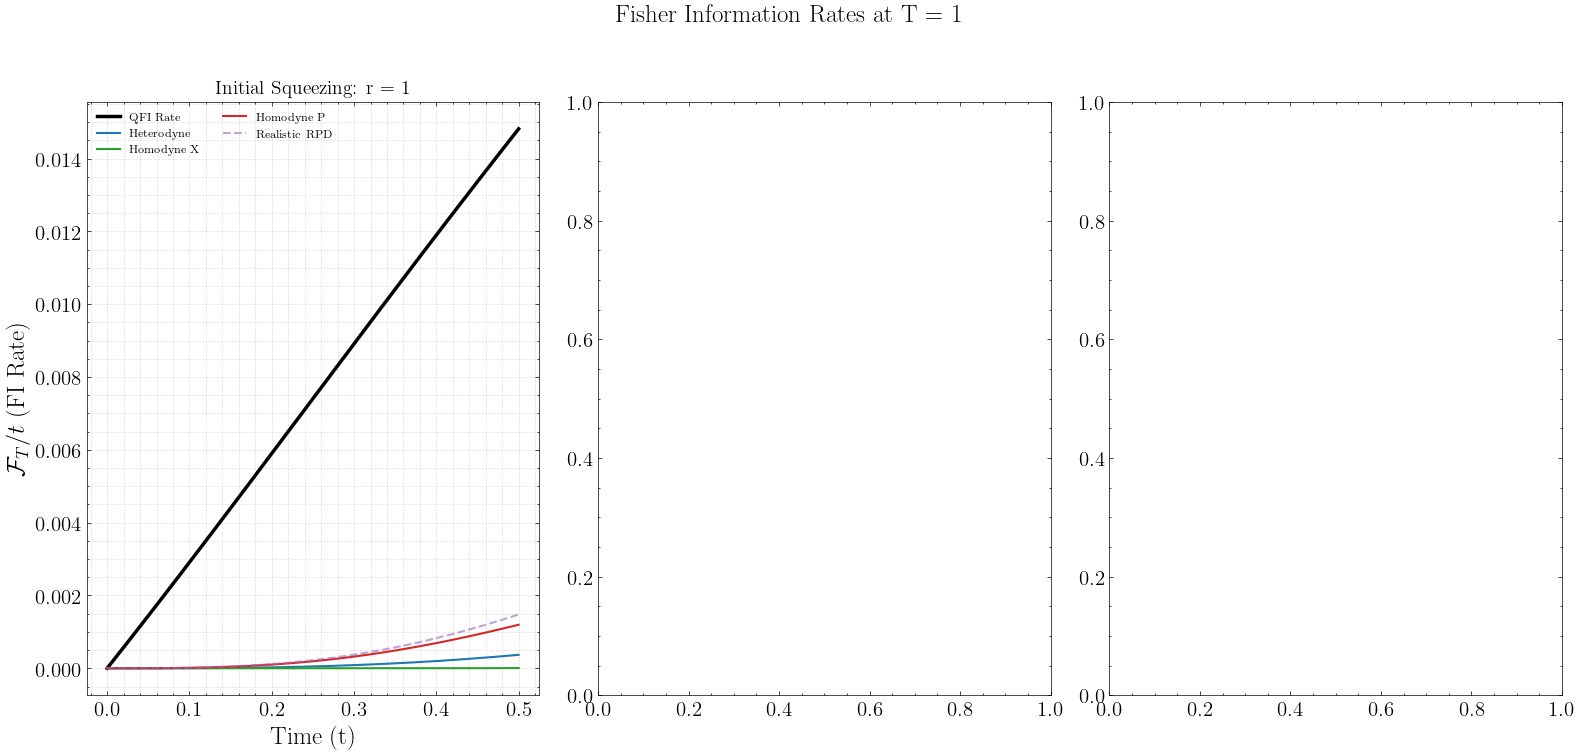

In [55]:
def generate_sigma0(r, theta):
    """
    Generates the rotated squeezed covariance matrix.
    r: squeezing magnitude (r < 1 position squeezed, r > 1 momentum squeezed)
    theta: squeezing angle in radians
    """
    # Base squeezed state (diagonal)
    sigma_base = 0.5 * np.array([[r, 0], 
                                 [0, 1.0/r]])
    
    # Rotation matrix
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, s], 
                  [-s, c]])
    
    # Apply rotation: R * sigma_base * R^T
    sigma0 = R @ sigma_base @ R.T
    return sigma0


def evolve_all_FI_dynamics(t_array, x0, p0, sigma0, alpha1, alpha2, Temp, gamma, G, Gdot, Gddot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real
    
    # System contribution to Covariance
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    # Arrays to store tracking variables (Values and Rates)
    FI_het, FI_hom_x, FI_hom_p, QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    FI_rpd_ideal, FI_rpd_real = np.zeros(N), np.zeros(N)
    
    rate_het, rate_hom_x, rate_hom_p, rate_QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    rate_rpd_ideal, rate_rpd_real = np.zeros(N), np.zeros(N)
    
    # Define Measurement Matrices
    sig_M_het = np.array([[0.5, 0.0], [0.0, 0.5]])
    sig_M_hom_x = np.array([[1e-9, 0.0], [0.0, 1e9]])
    sig_M_hom_p = np.array([[1e9, 0.0], [0.0, 1e-9]])
    
    def calc_classical_CFI(sig, dsig, sig_M):
        inv_term = np.linalg.inv(sig + sig_M)
        prod = np.dot(inv_term, dsig)
        return 0.5 * np.trace(np.dot(prod, prod))

    for i in tqdm(range(1, N), desc="Simulating Dynamics & FIs"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        t_current = t_array[i]
        
        # Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # 1. Classical FIs
        FI_het[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_het)
        FI_hom_x[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_x)
        FI_hom_p[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_p)
        
        phase = Omega_S * t_current
        c_rot = np.cos(phase)
        s_rot = np.sin(phase)
        
        # 2. Build the symplectic rotation matrix for the free oscillator
        S_rot = np.array([
            [c_rot,              s_rot / Omega_S],
            [-Omega_S * s_rot,   c_rot          ]
        ])
        
        # 3. Rotate the measurement basis to track the state
        sigma_M_adaptive = S_rot @ sigma0 @ S_rot.T
        
        # 4. Use the adaptive matrix for photodetection
        A_rpd = sigma_t + sigma_M_adaptive
        det_A = np.linalg.det(A_rpd)
        inv_A = np.linalg.inv(A_rpd)
        trace_term = np.trace(np.dot(inv_A, dsigma_t))
        
        P_0_base = 1.0 / np.sqrt(det_A)
        
        # Ideal RPD (P_D = 0)
        dP_0_ideal = -0.5 * P_0_base * trace_term
        FI_rpd_ideal[i] = (dP_0_ideal**2) / (P_0_base * (1.0 - P_0_base) + 1e-15)
        
        # Realistic RPD (P_D = 0.02)
        P_0_real = (1.0 - 0.1) * P_0_base
        dP_0_real = -0.5 * P_0_real * trace_term
        FI_rpd_real[i] = (dP_0_real**2) / (P_0_real * (1.0 - P_0_real) + 1e-15)

        # --- 3. Quantum FI (Using Analytical Formula from Appendix A) ---
        det_sigma = sigma_t[0,0]*sigma_t[1,1] - sigma_t[0,1]**2
        det_dsigma = dsigma_t[0,0]*dsigma_t[1,1] - dsigma_t[0,1]**2
        d_det_sigma = dsigma_t[0,0]*sigma_t[1,1] + sigma_t[0,0]*dsigma_t[1,1] - 2*sigma_t[0,1]*dsigma_t[0,1]
        
        epsilon = 1e-16 
        purity_term = np.maximum(det_sigma - 0.25, epsilon)
        
        term1 = 0.5 * (d_det_sigma**2) / (purity_term * (det_sigma + 0.25))
        term2 = det_dsigma / (det_sigma + 0.25)
        
        QFI[i] = term1 - term2
        
        # 4. Calculate Rates directly
        rate_het[i] = FI_het[i] / t_current
        rate_hom_x[i] = FI_hom_x[i] / t_current
        rate_hom_p[i] = FI_hom_p[i] / t_current
        rate_rpd_ideal[i] = FI_rpd_ideal[i] / t_current
        rate_rpd_real[i] = FI_rpd_real[i] / t_current
        rate_QFI[i] = QFI[i] / t_current
        
    return {
        "time": t_array, 
        "rate_het": rate_het, "rate_hom_x": rate_hom_x, "rate_hom_p": rate_hom_p, 
        "rate_rpd_ideal": rate_rpd_ideal, "rate_rpd_real": rate_rpd_real, "rate_QFI": rate_QFI
    }


# ==========================================
# 4. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # --- Physical Parameters ---
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 2.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    mass = 1.0
    
    # Simulation Time Grid
    times = np.linspace(0, 0.5, 10000)
    
    # Laplace Polynomials for the Green's Function
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    # Extract Green's Function and Derivatives
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
    Gdot = Gprime_of_t  
    
    x0 = 1.0
    p0 = 0.0

    # ---------------------------------------------------------
    # NEW SETUP: Fixed T, 4 squeezing values, unified execution
    # ---------------------------------------------------------
    T_fixed = 1  
    r_values = [1]
    theta = 0.0

    # Create a 2x2 grid for the 4 squeezing values
    fig, axes = plt.subplots(1, 3, figsize=(16, 8))
    fig.suptitle(f"Fisher Information Rates at T = {T_fixed}", fontsize=18, fontweight='bold')
    axes = axes.flatten()
    
    for i, (r, ax) in enumerate(zip(r_values, axes)):
        print(f"\n--- Simulating for Squeezing r = {r} ---")
        
        # Generate initial state
        sigma0 = generate_sigma0(r, theta)
        
        # Single execution call for ALL measurements!
        sol = evolve_all_FI_dynamics(
            times, x0, p0, sigma0, alpha1, alpha2, T_fixed, 
            gamma, G, Gdot, Gddot, mass
        )
        
        # 1. Plot QFI (Absolute Quantum Bound)
        ax.plot(sol["time"], sol["rate_QFI"], color='black', linewidth=2.5, label="QFI Rate")
        
        # 2. Plot Gaussian Measurements
        ax.plot(sol["time"], sol["rate_het"], color='tab:blue', linewidth=1.5, label="Heterodyne")
        ax.plot(sol["time"], sol["rate_hom_x"], color='tab:green', linewidth=1.5, label="Homodyne X")
        ax.plot(sol["time"], sol["rate_hom_p"], color='tab:red', linewidth=1.5, label="Homodyne P")
        
        # 3. Plot Photodetection (Light dashed lines)
        #ax.plot(sol["time"], sol["rate_rpd_ideal"], color='tab:orange', linestyle='--', alpha=0.6, linewidth=1.5, label="Ideal RPD")
        ax.plot(sol["time"], sol["rate_rpd_real"], color='tab:purple', linestyle='--', alpha=0.6, linewidth=1.5, label="Realistic RPD")
        
        # Formatting the subplot
        ax.set_title(f"Initial Squeezing: r = {r}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Time (t)")
        ax.set_ylabel(r"$\mathcal{F}_T / t$ (FI Rate)")
        
        # Log scale handles rates spanning multiple orders of magnitude
        #ax.set_yscale('log')
        #ax.set_xscale('log')
        #ax.set_ylim(0, 2e-14)
        ax.grid(True, which="both", ls="--", alpha=0.4)
        
        # Add legend 
        ax.legend(loc='best', fontsize='small', ncol=2)

    # Adjust layout to prevent title overlap
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    plt.show()

# QFI (coupling strength)


 Simulating for Temperature T = 0.1
 -> alpha1 = 10.000


Simulating Dynamics & FIs: 100%|██████████| 1999/1999 [00:04<00:00, 452.28it/s]


 -> alpha1 = 100.000


Simulating Dynamics & FIs: 100%|██████████| 1999/1999 [00:04<00:00, 431.40it/s]
C:\Users\usuario\AppData\Local\Temp\ipykernel_16712\2237107020.py:211: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 100)


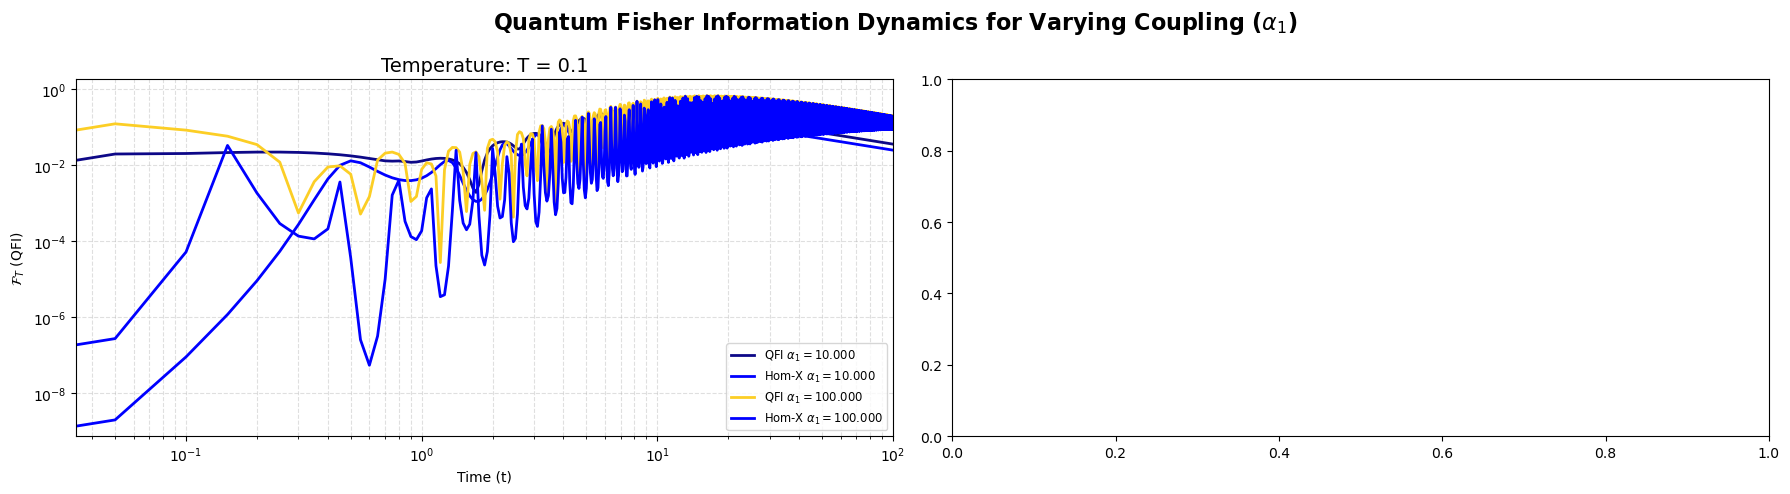

In [ ]:
def generate_sigma0(r, theta):
    """
    Generates the rotated squeezed covariance matrix.
    r: squeezing magnitude (r < 1 position squeezed, r > 1 momentum squeezed)
    theta: squeezing angle in radians
    """
    # Base squeezed state (diagonal)
    sigma_base = 0.5 * np.array([[r, 0], 
                                 [0, 1.0/r]])
    
    # Rotation matrix
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, s], 
                  [-s, c]])
    
    # Apply rotation: R * sigma_base * R^T
    sigma0 = R @ sigma_base @ R.T
    return sigma0


def evolve_all_FI_dynamics(t_array, sigma0, alpha1, alpha2, Temp, gamma, G, Gdot, Gddot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real
    
    # System contribution to Covariance
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    # Arrays to store tracking variables (Values and Rates)
    FI_het, FI_hom_x, FI_hom_p, QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    FI_rpd_ideal, FI_rpd_real = np.zeros(N), np.zeros(N)
    
    rate_het, rate_hom_x, rate_hom_p, rate_QFI, error_qfi = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    rate_rpd_ideal, rate_rpd_real = np.zeros(N), np.zeros(N)
    
    # Define Measurement Matrices
    sig_M_het = np.array([[0.5, 0.0], [0.0, 0.5]])
    sig_M_hom_x = np.array([[1e-9, 0.0], [0.0, 1e9]])
    sig_M_hom_p = np.array([[1e9, 0.0], [0.0, 1e-9]])
    
    def calc_classical_CFI(sig, dsig, sig_M):
        inv_term = np.linalg.inv(sig + sig_M)
        prod = np.dot(inv_term, dsig)
        return 0.5 * np.trace(np.dot(prod, prod))

    for i in tqdm(range(1, N), desc="Simulating Dynamics & FIs"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        # Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # 1. Classical FIs
        FI_het[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_het)
        FI_hom_x[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_x)
        FI_hom_p[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_p)
        
        # --- 2. Photodetection FIs (Ideal & Realistic) ---
        A_rpd = sigma_t + sig_M_het
        det_A = np.linalg.det(A_rpd)
        inv_A = np.linalg.inv(A_rpd)
        trace_term = np.trace(np.dot(inv_A, dsigma_t))
        
        P_0_base = 1.0 / np.sqrt(det_A)
        
        # Ideal RPD (P_D = 0)
        dP_0_ideal = -0.5 * P_0_base * trace_term
        FI_rpd_ideal[i] = (dP_0_ideal**2) / (P_0_base * (1.0 - P_0_base) + 1e-15)
        
        # Realistic RPD (P_D = 0.02)
        P_0_real = (1.0 - 0.02) * P_0_base
        dP_0_real = -0.5 * P_0_real * trace_term
        FI_rpd_real[i] = (dP_0_real**2) / (P_0_real * (1.0 - P_0_real) + 1e-15)

        # --- 3. Quantum FI (Using Analytical Formula from Appendix A) ---
        det_sigma = sigma_t[0,0]*sigma_t[1,1] - sigma_t[0,1]**2
        det_dsigma = dsigma_t[0,0]*dsigma_t[1,1] - dsigma_t[0,1]**2
        d_det_sigma = dsigma_t[0,0]*sigma_t[1,1] + sigma_t[0,0]*dsigma_t[1,1] - 2*sigma_t[0,1]*dsigma_t[0,1]
        
        epsilon = 1e-16 
        purity_term = np.maximum(det_sigma - 0.25, epsilon)
        
        term1 = 0.5 * (d_det_sigma**2) / (purity_term * (det_sigma + 0.25))
        term2 = det_dsigma / (det_sigma + 0.25)
        
        QFI[i] = term1 - term2
        
        
        # 4. Calculate Rates directly
        t_current = t_array[i]
        rate_het[i] = FI_het[i]
        rate_hom_x[i] = FI_hom_x[i]/t_current
        rate_hom_p[i] = FI_hom_p[i]
        rate_rpd_ideal[i] = FI_rpd_ideal[i]
        rate_rpd_real[i] = FI_rpd_real[i]
        rate_QFI[i] = QFI[i] /t_current
        
    return {
        "time": t_array, 
        "rate_het": rate_het, "rate_hom_x": rate_hom_x, "rate_hom_p": rate_hom_p, 
        "rate_rpd_ideal": rate_rpd_ideal, "rate_rpd_real": rate_rpd_real, "rate_QFI": rate_QFI, "error_qfi": error_qfi
    }

# ==========================================
# 4. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # --- Fixed Physical Parameters ---
    gamma = 1.0
    alpha2 = 2.0
    Omega_S_bare = 1.0
    mass = 1.0
    
    # Simulation Time Grid
    times = np.linspace(0, 100, 2000)
    
    # Initial State (Fixed to Vacuum/Coherent state r=1)
    r = 1.0
    theta = 0.0
    sigma0 = generate_sigma0(r, theta)
    x0 = 0.0
    p0 = 0.0

    # Dummy measurement matrix (needed for the function to run, but we only plot QFI)
    sigma_M = np.array([[0.5, 0.0], [0.0, 0.5]])

    # ---------------------------------------------------------
    # NEW SETUP: Varying alpha_1 at specific Temperatures
    # ---------------------------------------------------------
    temperaturas = [0.1]
    alpha1_values = np.array([10, 100])
    
    import matplotlib.cm as cm
    # Using plasma colormap for distinct visibility
    colores_alpha = cm.plasma(np.linspace(0, 0.9, len(alpha1_values)))

    # Create a 1x3 grid for the 3 temperatures
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle(r"Quantum Fisher Information Dynamics for Varying Coupling ($\alpha_1$)", fontsize=16, fontweight='bold')
    
    for i, (temp, ax) in enumerate(zip(temperaturas, axes)):
        print(f"\n========================================")
        print(f" Simulating for Temperature T = {temp}")
        print(f"========================================")
        
        for alpha1, color in zip(alpha1_values, colores_alpha):
            print(f" -> alpha1 = {alpha1:.3f}")
            
            # 1. Recompute system frequencies that depend on alpha1
            delta_Omega_s = np.sqrt(alpha1)
            Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
            
            # 2. Recompute Laplace Polynomials for the Green's Function
            B = [1, gamma, alpha2 * gamma]
            A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
            
            # 3. Extract Green's Function and Derivative
            info = inverse_laplace_rational(B, A)
            G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
            Gdot = Gprime_of_t
            
            # 4. Run Simulation
            sol = evolve_all_FI_dynamics(times, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, Gddot, mass)
            
            # 5. Plot QFI
            ax.plot(sol["time"], sol["rate_QFI"], color=color, linewidth=2, label=rf"QFI $\alpha_1 = {alpha1:.3f}$")
            ax.plot(sol["time"], sol["rate_hom_x"], color='blue', linewidth=2, label=rf"Hom-X $\alpha_1 = {alpha1:.3f}$")
            

        # Formatting each subplot
        ax.set_title(f"Temperature: T = {temp}", fontsize=14)
        ax.set_xlabel("Time (t)")
        if i == 0:
            ax.set_ylabel(r"$\mathcal{F}_T$ (QFI)")
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlim(0, 100)
        ax.grid(True, which="both", ls="--", alpha=0.4)
        
        ax.legend(loc='best', fontsize='small')

    plt.tight_layout()
    plt.show()

# Fisher Rate for Squeezing

Sweeping Squeezing Parameters (T=0.0001)...
  -> Simulating r = 0.001


Simulating Dynamics & FIs: 100%|██████████| 999/999 [00:01<00:00, 773.47it/s]


  -> Simulating r = 1


Simulating Dynamics & FIs: 100%|██████████| 999/999 [00:01<00:00, 833.72it/s] 


  -> Simulating r = 1000.0


Simulating Dynamics & FIs: 100%|██████████| 999/999 [00:01<00:00, 940.63it/s] 
C:\Users\usuario\AppData\Local\Temp\ipykernel_17192\4031227781.py:210: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right', fontsize=8)


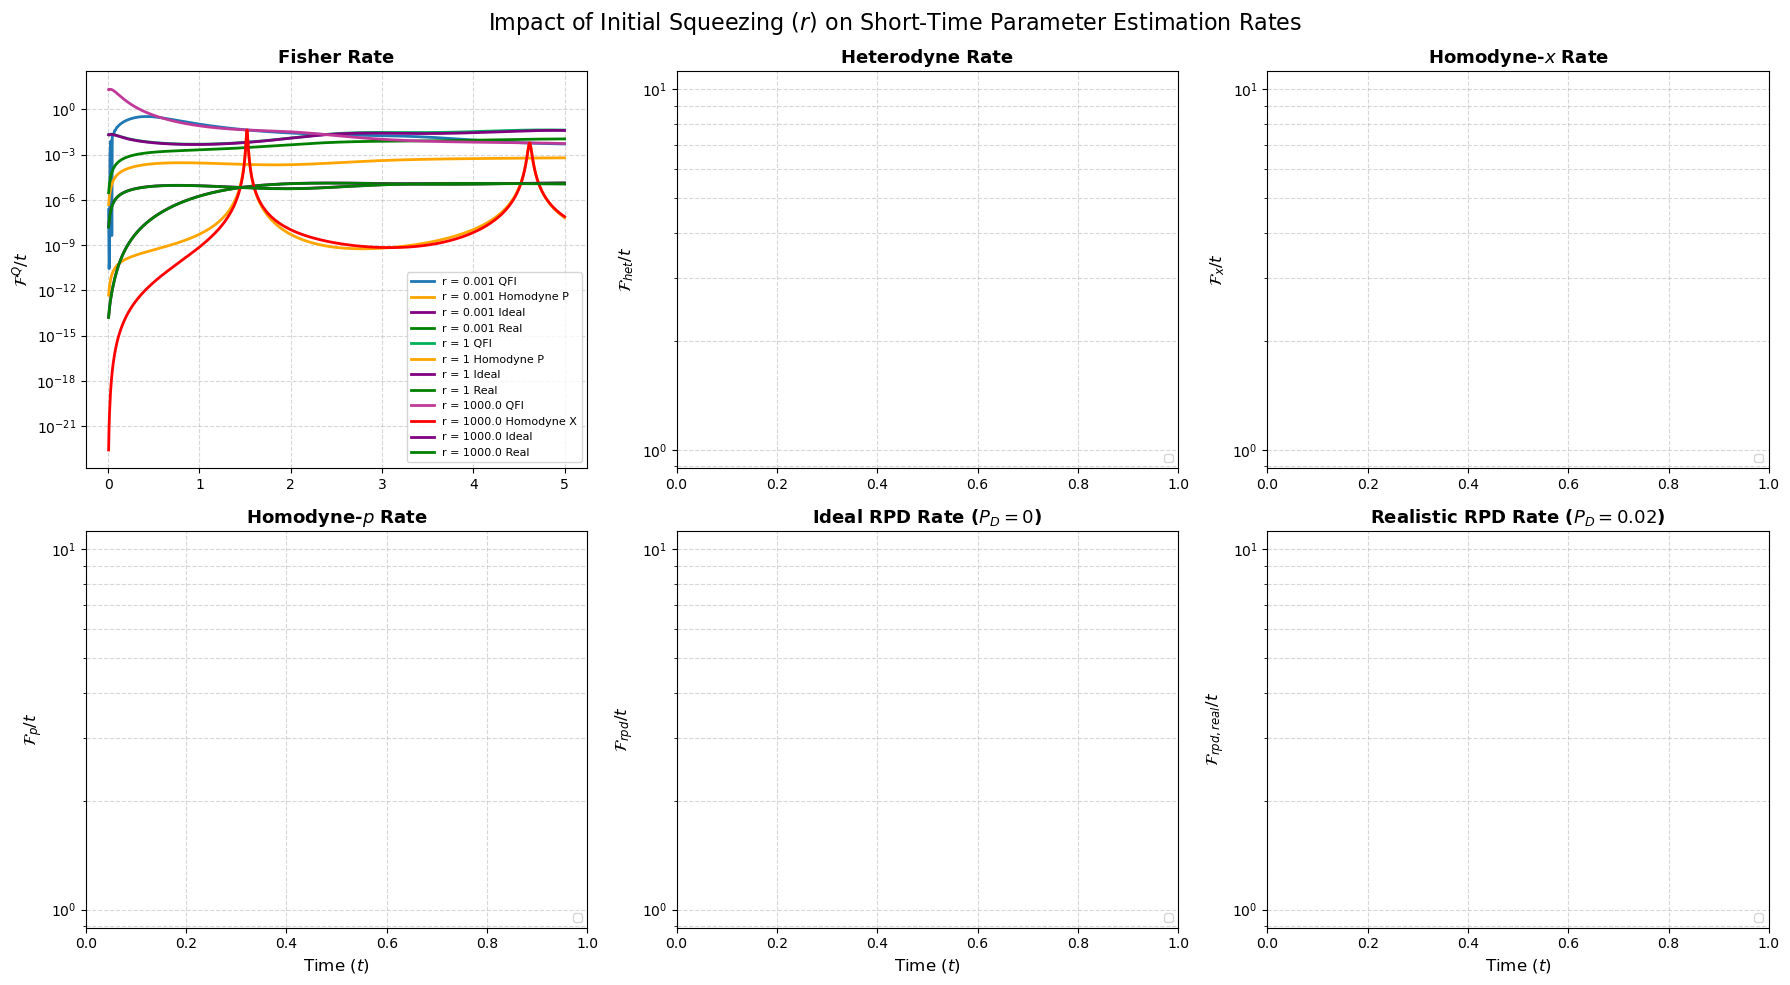

In [ ]:
def generate_sigma0(r, theta):
    """
    Generates the rotated squeezed covariance matrix.
    r: squeezing magnitude (r < 1 position squeezed, r > 1 momentum squeezed)
    theta: squeezing angle in radians
    """
    # Base squeezed state (diagonal)
    sigma_base = 0.5 * np.array([[r, 0], 
                                 [0, 1.0/r]])
    
    # Rotation matrix
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, s], 
                  [-s, c]])
    
    # Apply rotation: R * sigma_base * R^T
    sigma0 = R @ sigma_base @ R.T
    return sigma0

def evolve_all_FI_dynamics(t_array, x0, p0, sigma0, alpha1, alpha2, Temp, gamma, G, Gdot, Gddot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real
    
    # System contribution to Covariance
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    # Arrays to store tracking variables (Values and Rates)
    FI_het, FI_hom_x, FI_hom_p, QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    FI_rpd_ideal, FI_rpd_real = np.zeros(N), np.zeros(N)
    
    rate_het, rate_hom_x, rate_hom_p, rate_QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    rate_rpd_ideal, rate_rpd_real = np.zeros(N), np.zeros(N)
    
    # Define Measurement Matrices
    sig_M_het = np.array([[0.5, 0.0], [0.0, 0.5]])
    sig_M_hom_x = np.array([[1e-9, 0.0], [0.0, 1e9]])
    sig_M_hom_p = np.array([[1e9, 0.0], [0.0, 1e-9]])

    
    def calc_classical_CFI(sig, dsig, sig_M):
        inv_term = np.linalg.inv(sig + sig_M)
        prod = np.dot(inv_term, dsig)
        return 0.5 * np.trace(np.dot(prod, prod))

    for i in tqdm(range(1, N), desc="Simulating Dynamics & FIs"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        # Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # 1. Classical FIs
        FI_het[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_het)
        FI_hom_x[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_x)
        FI_hom_p[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_p)
        
        # --- 2. Photodetection FIs (Ideal & Realistic) ---
        A_rpd = sigma_t + sig_M_het
        det_A = np.linalg.det(A_rpd)
        inv_A = np.linalg.inv(A_rpd)
        trace_term = np.trace(np.dot(inv_A, dsigma_t))
        
        P_0_base = 1.0 / np.sqrt(det_A)
        
        # Ideal RPD (P_D = 0)
        dP_0_ideal = -0.5 * P_0_base * trace_term
        FI_rpd_ideal[i] = (dP_0_ideal**2) / (P_0_base * (1.0 - P_0_base) + 1e-15)
        
        # Realistic RPD (P_D = 0.02)
        P_0_real = (1.0 - 0.02) * P_0_base
        dP_0_real = -0.5 * P_0_real * trace_term
        FI_rpd_real[i] = (dP_0_real**2) / (P_0_real * (1.0 - P_0_real) + 1e-15)

        # --- 3. Quantum FI (Using Analytical Formula from Appendix A) ---
        det_sigma = sigma_t[0,0]*sigma_t[1,1] - sigma_t[0,1]**2
        det_dsigma = dsigma_t[0,0]*dsigma_t[1,1] - dsigma_t[0,1]**2
        d_det_sigma = dsigma_t[0,0]*sigma_t[1,1] + sigma_t[0,0]*dsigma_t[1,1] - 2*sigma_t[0,1]*dsigma_t[0,1]
        
        epsilon = 1e-16 
        purity_term = np.maximum(det_sigma - 0.25, epsilon)
        
        term1 = 0.5 * (d_det_sigma**2) / (purity_term * (det_sigma + 0.25))
        term2 = det_dsigma / (det_sigma + 0.25)
        
        QFI[i] = term1 - term2
        
        # 4. Calculate Rates directly
        t_current = t_array[i]
        rate_het[i] = FI_het[i] / t_current
        rate_hom_x[i] = FI_hom_x[i] / t_current
        rate_hom_p[i] = FI_hom_p[i] / t_current
        rate_rpd_ideal[i] = FI_rpd_ideal[i] / t_current
        rate_rpd_real[i] = FI_rpd_real[i] / t_current
        rate_QFI[i] = QFI[i] / t_current
        
    return {
        "time": t_array, 
        "rate_het": rate_het, "rate_hom_x": rate_hom_x, "rate_hom_p": rate_hom_p, 
        "rate_rpd_ideal": rate_rpd_ideal, "rate_rpd_real": rate_rpd_real, "rate_QFI": rate_QFI
    }

# ==========================================
# 4. EXECUTION BLOCK (2x3 GRID)
# ==========================================
if __name__ == "__main__":
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 2.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    temp = 0.0001
    mass = 1.0
    
    # Short time grid focused on transient rates
    times = np.linspace(0, 5, 1000)
    
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
    Gdot = Gprime_of_t
    
    x0, p0 = 0.0, 0.0
    theta_fixed = 0
    r_values = [1e-3, 1, 1e3]
    colors = ['#1f77b4', '#00b159', "#c03998", '#ffc425', '#d11141'] 

    # --- Use a 2x3 Grid to cleanly display all 6 rates ---
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    ax_qfi, ax_het, ax_homx = axs[0, 0], axs[0, 1], axs[0, 2]
    ax_homp, ax_rpdi, ax_rpdr = axs[1, 0], axs[1, 1], axs[1, 2]

    print(f"Sweeping Squeezing Parameters (T={temp})...")
    
    for r, color in zip(r_values, colors):
        print(f"  -> Simulating r = {r}")
        sigma0 = generate_sigma0(r, theta_fixed)

        sol = evolve_all_FI_dynamics(times, x0, p0, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, Gddot, mass)
        
        valid_times = sol["time"][1:]
        label_str = f"r = {r}"
        
        # Plot individual rates across subplots
        ax_qfi.plot(valid_times, sol["rate_QFI"][1:], color=color, linewidth=2, label=f"r = {r} QFI")
        #ax_qfi.plot(valid_times, sol["rate_het"][1:], color=color, linewidth=2, label=label_str)
        if r == 1e3:
            ax_qfi.plot(valid_times, sol["rate_hom_x"][1:], color='red', linewidth=2, label=f"r = {r} Homodyne X")
            ax_qfi.plot(valid_times, sol["rate_rpd_ideal"][1:], color='purple', linewidth=2, label=f"r = {r} Ideal")
            ax_qfi.plot(valid_times, sol["rate_rpd_real"][1:], color='green', linewidth=2, label=f"r = {r} Real")
        else:
            ax_qfi.plot(valid_times, sol["rate_hom_p"][1:], color='orange', linewidth=2, label=f"r = {r} Homodyne P")
            ax_qfi.plot(valid_times, sol["rate_rpd_ideal"][1:], color='purple', linewidth=2, label=f"r = {r} Ideal")
            ax_qfi.plot(valid_times, sol["rate_rpd_real"][1:], color='green', linewidth=2, label=f"r = {r} Real")
        

    # --- Formatting all 6 Subplots ---
    axes = [ax_qfi, ax_het, ax_homx, ax_homp, ax_rpdi, ax_rpdr]
    titles = [
        "Fisher Rate", "Heterodyne Rate", "Homodyne-$x$ Rate", 
        "Homodyne-$p$ Rate", "Ideal RPD Rate ($P_D=0$)", "Realistic RPD Rate ($P_D=0.02$)"
    ]
    ylabels = [
        r"$\mathcal{F}^Q / t$", r"$\mathcal{F}_{het} / t$", r"$\mathcal{F}_{x} / t$", 
        r"$\mathcal{F}_{p} / t$", r"$\mathcal{F}_{rpd} / t$", r"$\mathcal{F}_{rpd, real} / t$"
    ]

    for ax, title, ylabel in zip(axes, titles, ylabels):
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_yscale('log')
        ax.grid(True, which="both", ls="--", alpha=0.5)
        ax.legend(loc='lower right', fontsize=8)
        
        if ax in [ax_homp, ax_rpdi, ax_rpdr]:
            ax.set_xlabel("Time ($t$)", fontsize=12)

    plt.suptitle("Impact of Initial Squeezing ($r$) on Short-Time Parameter Estimation Rates", fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

# Fisher Rate for different initial correlations

Sweeping Squeezing Parameters (T=1)...
  -> Simulating r = 1


Simulating Dynamics & FIs: 100%|██████████| 3999/3999 [00:17<00:00, 231.46it/s]


  -> Simulating r = 1


Simulating Dynamics & FIs: 100%|██████████| 3999/3999 [00:13<00:00, 301.69it/s]


  -> Simulating r = 1


Simulating Dynamics & FIs: 100%|██████████| 3999/3999 [00:11<00:00, 333.58it/s]


  -> Simulating r = 1


Simulating Dynamics & FIs:   0%|          | 0/3999 [00:00<?, ?it/s]C:\Users\usuario\AppData\Local\Temp\ipykernel_17192\3874870162.py:81: RuntimeWarning: invalid value encountered in sqrt
  P_0_base = 1.0 / np.sqrt(det_A)
Simulating Dynamics & FIs: 100%|██████████| 3999/3999 [00:12<00:00, 328.42it/s]


  -> Simulating r = 1


Simulating Dynamics & FIs: 100%|██████████| 3999/3999 [00:14<00:00, 272.20it/s]


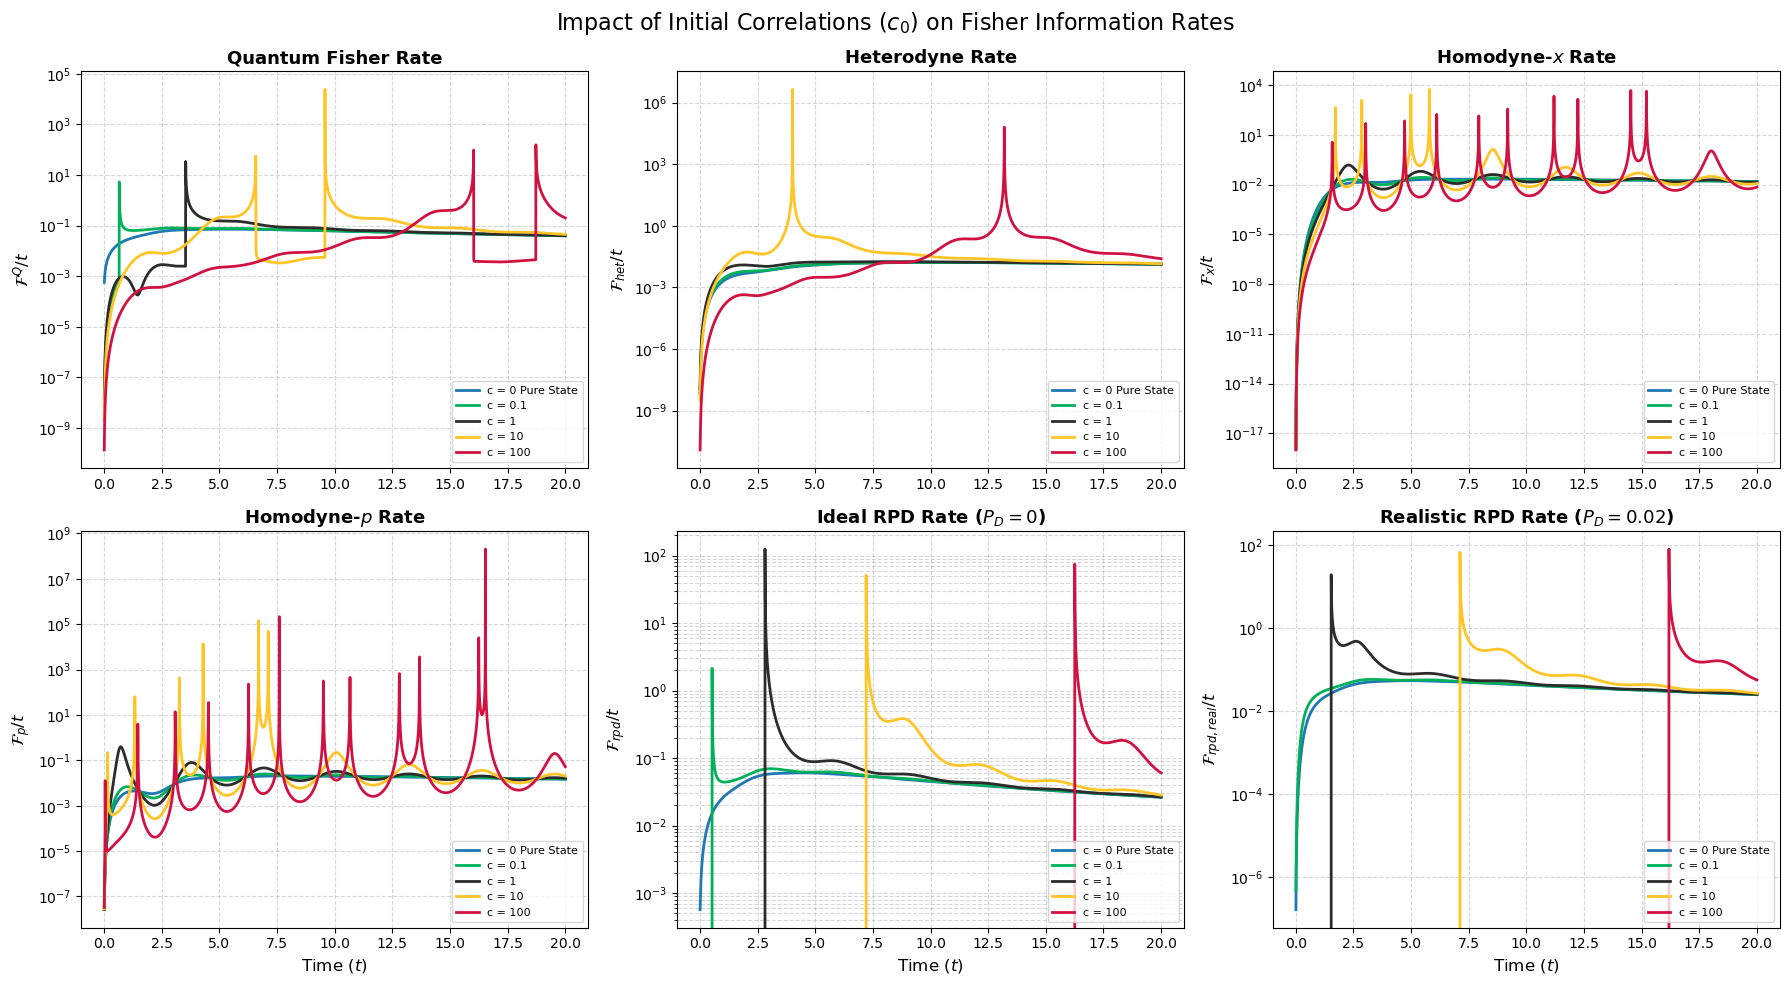

In [ ]:
def evolve_all_FI_dynamics(t_array, x0, p0, sigma0, alpha1, alpha2, Temp, gamma, G, Gdot, Gddot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real
    
    # System contribution to Covariance
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    # Arrays to store tracking variables (Values and Rates)
    FI_het, FI_hom_x, FI_hom_p, QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    FI_rpd_ideal, FI_rpd_real = np.zeros(N), np.zeros(N)
    
    rate_het, rate_hom_x, rate_hom_p, rate_QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    rate_rpd_ideal, rate_rpd_real = np.zeros(N), np.zeros(N)
    
    # Define Measurement Matrices
    sig_M_het = np.array([[0.5, 0.0], [0.0, 0.5]])
    sig_M_hom_x = np.array([[1e-6, 0.0], [0.0, 1e6]])
    sig_M_hom_p = np.array([[1e6, 0.0], [0.0, 1e-6]])
    
    def calc_classical_CFI(sig, dsig, sig_M):
        inv_term = np.linalg.inv(sig + sig_M)
        prod = np.dot(inv_term, dsig)
        return 0.5 * np.trace(np.dot(prod, prod))

    for i in tqdm(range(1, N), desc="Simulating Dynamics & FIs"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        t_current = t_array[i]
        
        # Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # 1. Classical FIs
        FI_het[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_het)
        FI_hom_x[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_x)
        FI_hom_p[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_p)
        
        # --- 2. Photodetection FIs (Ideal & Realistic) ---
        A_rpd = sigma_t + sig_M_het
        det_A = np.linalg.det(A_rpd)
        inv_A = np.linalg.inv(A_rpd)
        trace_term = np.trace(np.dot(inv_A, dsigma_t))
        
        P_0_base = 1.0 / np.sqrt(det_A)
        
        # Ideal RPD (P_D = 0)
        dP_0_ideal = -0.5 * P_0_base * trace_term
        FI_rpd_ideal[i] = (dP_0_ideal**2) / (P_0_base * (1.0 - P_0_base) + 1e-15)
        
        # Realistic RPD (P_D = 0.02)
        P_0_real = (1.0 - 0.02) * P_0_base
        dP_0_real = -0.5 * P_0_real * trace_term
        FI_rpd_real[i] = (dP_0_real**2) / (P_0_real * (1.0 - P_0_real) + 1e-15)

        # --- 3. Quantum FI (Using Analytical Formula from Appendix A) ---
        det_sigma = sigma_t[0,0]*sigma_t[1,1] - sigma_t[0,1]**2
        det_dsigma = dsigma_t[0,0]*dsigma_t[1,1] - dsigma_t[0,1]**2
        d_det_sigma = dsigma_t[0,0]*sigma_t[1,1] + sigma_t[0,0]*dsigma_t[1,1] - 2*sigma_t[0,1]*dsigma_t[0,1]
        
        epsilon = 1e-16 
        purity_term = np.maximum(det_sigma - 0.25, epsilon)
        
        term1 = 0.5 * (d_det_sigma**2) / (purity_term * (det_sigma + 0.25))
        term2 = det_dsigma / (det_sigma + 0.25)
        
        QFI[i] = term1 - term2
        
        # 4. Calculate Rates directly
        rate_het[i] = FI_het[i] / t_current
        rate_hom_x[i] = FI_hom_x[i] / t_current
        rate_hom_p[i] = FI_hom_p[i] / t_current
        rate_rpd_ideal[i] = FI_rpd_ideal[i] / t_current
        rate_rpd_real[i] = FI_rpd_real[i] / t_current
        rate_QFI[i] = QFI[i] / t_current
        
    return {
        "time": t_array, 
        "rate_het": rate_het, "rate_hom_x": rate_hom_x, "rate_hom_p": rate_hom_p, 
        "rate_rpd_ideal": rate_rpd_ideal, "rate_rpd_real": rate_rpd_real, "rate_QFI": rate_QFI
    }

# ==========================================
# 4. EXECUTION BLOCK (2x3 GRID)
# ==========================================
if __name__ == "__main__":
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 2.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    temp = 1
    mass = 1.0
    
    # Short time grid focused on transient rates
    times = np.linspace(0, 20, 4000)
    
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
    Gdot = Gprime_of_t
    
    x0, p0 = 0.0, 0.0
    r = 1
    c_0_values = [0, 0.1, 1.02, 10, 100]
    colors = ['#1f77b4', '#00b159', '#2c2c2c', '#ffc425', '#d11141'] 

    # --- Use a 2x3 Grid to cleanly display all 6 rates ---
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    ax_qfi, ax_het, ax_homx = axs[0, 0], axs[0, 1], axs[0, 2]
    ax_homp, ax_rpdi, ax_rpdr = axs[1, 0], axs[1, 1], axs[1, 2]

    print(f"Sweeping Squeezing Parameters (T={temp})...")
    
    for c, color in zip(c_0_values, colors):
        print(f"  -> Simulating c_0 = {c}")
        sigma0 = 0.5 * np.array([[r, np.sqrt(c)], [np.sqrt(c), 1.0/r]])

        sol = evolve_all_FI_dynamics(times, x0, p0, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, Gddot, mass)
        
        valid_times = sol["time"][1:]
        label_str = f"c = {c}" if c != 0 else "c = 0 Pure State"
        
        # Plot individual rates across subplots
        ax_qfi.plot(valid_times, sol["rate_QFI"][1:], color=color, linewidth=2, label=label_str)
        ax_het.plot(valid_times, sol["rate_het"][1:], color=color, linewidth=2, label=label_str)
        ax_homx.plot(valid_times, sol["rate_hom_x"][1:], color=color, linewidth=2, label=label_str)
        ax_homp.plot(valid_times, sol["rate_hom_p"][1:], color=color, linewidth=2, label=label_str)
        ax_rpdi.plot(valid_times, sol["rate_rpd_ideal"][1:], color=color, linewidth=2, label=label_str)
        ax_rpdr.plot(valid_times, sol["rate_rpd_real"][1:], color=color, linewidth=2, label=label_str)

    # --- Formatting all 6 Subplots ---
    axes = [ax_qfi, ax_het, ax_homx, ax_homp, ax_rpdi, ax_rpdr]
    titles = [
        "Quantum Fisher Rate", "Heterodyne Rate", "Homodyne-$x$ Rate", 
        "Homodyne-$p$ Rate", "Ideal RPD Rate ($P_D=0$)", "Realistic RPD Rate ($P_D=0.02$)"
    ]
    ylabels = [
        r"$\mathcal{F}^Q / t$", r"$\mathcal{F}_{het} / t$", r"$\mathcal{F}_{x} / t$", 
        r"$\mathcal{F}_{p} / t$", r"$\mathcal{F}_{rpd} / t$", r"$\mathcal{F}_{rpd, real} / t$"
    ]

    for ax, title, ylabel in zip(axes, titles, ylabels):
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_yscale('log')
        ax.grid(True, which="both", ls="--", alpha=0.5)
        ax.legend(loc='lower right', fontsize=8)
        
        if ax in [ax_homp, ax_rpdi, ax_rpdr]:
            ax.set_xlabel("Time ($t$)", fontsize=12)

    plt.suptitle("Impact of Initial Correlations ($c_0$) on Fisher Information Rates", fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

# Short-Time Limit


--- Simulando para T = 1 ---


Simulating Dynamics & FI: 100%|██████████| 1999/1999 [00:05<00:00, 347.81it/s]


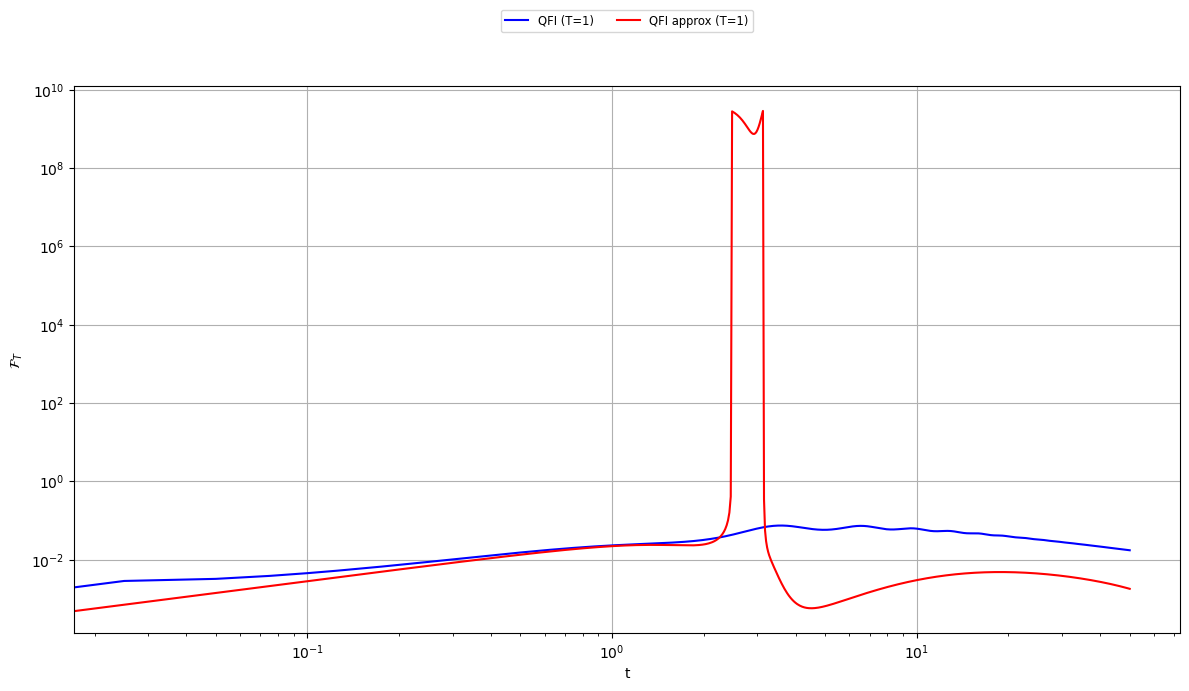

In [ ]:

def evolve_FI_dynamics(t_array, x0, p0, sigma0, sigma_M, alpha1, alpha2, Temp, gamma, G, Gdot, Omega, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = -(Omega**2) * G_r 

    # Exact system contribution for the numerical calculation
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Initial Constants for analytical expansion
    a0, b0, c0 = sx0, sp0, sxp0
    
    # Precompute noise grids
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass
    
    # Extract noise and temperature derivatives at t=0
    nu0 = nu_grid[0]
    dnu0 = dnu_grid[0]
    
    # First derivative of noise kernel w.r.t time (using forward finite difference)
    nu_dot0 = (nu_grid[1] - nu_grid[0]) / dt
    dnu_dot0 = (dnu_grid[1] - dnu_grid[0]) / dt
    
    # Arrays to store results
    fisher_info_t = np.zeros(N)
    var_x_total = np.zeros(N)
    var_p_total = np.zeros(N)
    QFI_exact = np.zeros(N)
    QFI_short_time = np.zeros(N)

    for i in tqdm(range(1, N), desc="Simulating Dynamics & FI"):
        t = t_array[i]
        
        # =========================================================
        # 1. SHORT-TIME ANALYTICAL EXPANSION
        # =========================================================
        
        # Core Green's functions
        G_t     = t - (Omega**2 / 6)*t**3 + (Omega**4 / 120)*t**5
        Gdot_t  = 1 - (Omega**2 / 2)*t**2 + (Omega**4 / 24)*t**4
        Gddot_t = -(Omega**2) * G_t
        
        # Auxiliary integrals: I_G(t) = int G(s)ds, J_G(t) = int s*G(s)ds
        I_G_t   = (1/2)*t**2 - (Omega**2 / 24)*t**4 + (Omega**4 / 720)*t**6
        J_G_t   = (1/3)*t**3 - (Omega**2 / 30)*t**5 + (Omega**4 / 840)*t**7
        
        # J_Gdot(t) = int s*Gdot(s)ds = t*G(t) - I_G(t)
        J_Gdot_t = t * G_t - I_G_t

        # System Contributions
        sys_xx = (Gdot_t**2) * a0 + (G_t**2) * b0 + 2 * G_t * Gdot_t * c0
        sys_pp = (Gddot_t**2) * a0 + (Gdot_t**2) * b0 + 2 * Gddot_t * Gdot_t * c0
        sys_xp = (Gdot_t * Gddot_t) * a0 + (G_t * Gdot_t) * b0 + (Gdot_t**2 + G_t * Gddot_t) * c0

        # Bath Contributions (including \dot{\nu}_0)
        # Note: nu_dot0 vanishes for xx and pp due to antisymmetry of (s1 - s2)
        bath_xx = nu0 * (I_G_t**2)
        bath_pp = nu0 * (G_t**2)
        bath_xp = nu0 * I_G_t * G_t + nu_dot0 * (J_G_t * G_t - I_G_t * J_Gdot_t)
        
        # Derivatives of bath contributions (System has no temperature dependence)
        dbath_xx = dnu0 * (I_G_t**2)
        dbath_pp = dnu0 * (G_t**2)
        dbath_xp = dnu0 * I_G_t * G_t + dnu_dot0 * (J_G_t * G_t - I_G_t * J_Gdot_t)

        # Total Approximate Covariance & Derivatives
        s_xx = sys_xx + bath_xx
        s_pp = sys_pp + bath_pp
        s_xp = sys_xp + bath_xp
        
        ds_xx = dbath_xx
        ds_pp = dbath_pp
        ds_xp = dbath_xp
        
        # Determinant QFI Formula
        det_s = s_xx * s_pp - s_xp**2
        det_ds = ds_xx * ds_pp - ds_xp**2
        d_det_s = (ds_xx * s_pp + s_xx * ds_pp - 2 * s_xp * ds_xp)
        
        pur_diff = max(det_s - 0.25, 1e-12)
        QFI_short_time[i] = (0.5 * (d_det_s**2) / (pur_diff * (det_s + 0.25)) + det_ds / (det_s + 0.25))/t
        
        # =========================================================
        # 2. EXACT NUMERICAL CALCULATION (Your original logic)
        # =========================================================
        
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        # Assuming matmul_toeplitz is defined in your environment
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        var_x_total[i] = sigma_t[0, 0]
        var_p_total[i] = sigma_t[1, 1]
        
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        
        dsigma_t = np.array([
            [np.dot(G_slice, dyG) * dt**2, np.dot(G_slice, dyGd) * dt**2],
            [np.dot(G_slice, dyGd) * dt**2, np.dot(Gd_slice, dyGd) * dt**2]
        ])
        
        # Classical Fisher Information
        inverse_term = np.linalg.inv(sigma_t + sigma_M)
        matrix_prod = np.dot(inverse_term, dsigma_t)
        fisher_info_t[i] = 0.5 * np.trace(np.dot(matrix_prod, matrix_prod))

        # --- 3. Quantum FI (Using Analytical Formula from Appendix B) ---
                        
        # 3.a) Calculate determinants explicitly for 2x2 matrices
        det_sigma = sigma_t[0,0]*sigma_t[1,1] - sigma_t[0,1]**2
        det_dsigma = dsigma_t[0,0]*dsigma_t[1,1] - dsigma_t[0,1]**2
        
        # 3.b) Calculate the temperature derivative of the determinant (Eq. B15)
        d_det_sigma = dsigma_t[0,0]*sigma_t[1,1] + sigma_t[0,0]*dsigma_t[1,1] - 2*sigma_t[0,1]*dsigma_t[0,1]
        
        # 3.c) Apply Eq. (B20)
        # We use a tiny epsilon max-gate to prevent strict ZeroDivision at exactly t=0
        # since det_sigma approaches 0.25 for pure states.
        epsilon = 1e-16 
        purity_term = np.maximum(det_sigma - 0.25, epsilon)
        
        term1 = 0.5 * (d_det_sigma**2) / (purity_term * (det_sigma + 0.25))
        term2 = det_dsigma / (det_sigma + 0.25)
        
        QFI_exact[i] = term1 - term2
            
    return {
        "time": t_array, 
        "var_x": var_x_total, 
        "var_p": var_p_total, 
        "FI": fisher_info_t, 
        "QFI": QFI_exact, 
        "QFI_short_time": QFI_short_time
    }

# ==========================================
# 4. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # --- Physical Parameters (Replace with your actual values) ---
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 2.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    mass = 1.0
    temperaturas = [1]
    
    # Simulation Time Grid
    times = np.linspace(0, 1, 2000)
    
    # Laplace Polynomials for the Green's Function
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    # Extract Green's Function and Derivative
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])

    # evaluate inverse Laplace
    Gdot = Gprime_of_t
    
    x0 = 1.0
    p0 = 0.0

    r = 1

    sigma0 = np.array([[r/2, 0], 
                       [0, 1/(2*r)]])
    
    # ---------------------------------------------------------
    # DEFINE YOUR MEASUREMENT NOISE MATRIX HERE
    # Example 1: Homodyne (x-quadrature measurement) 
    sigma_M = np.array([[1/2, 0.0], [0.0, 1/2]])  # Large noise on p
    # Example 2: Heterodyne (symmetric measurement)
    #sigma_M = np.array([[0.5, 0.0], [0.0, 0.5]])
    # ---------------------------------------------------------

    # ==========================================
    # 5. LOOP OVER TEMPERATURES & PLOT RESULTS
    # ==========================================
    
    #colores = ['blue', 'orange', 'green', 'red']
    colores = ['blue']
    
    plt.figure(figsize=(12, 7))

    for temp, color in zip(temperaturas, colores):
        print(f"\n--- Simulando para T = {temp} ---")
        
        # Run Simulation for current temperature
        sol = evolve_FI_dynamics(times, x0, p0, sigma0, sigma_M, alpha1, alpha2, temp, gamma, G, Gdot, Omega_S, mass)

        # Thermal Asymptote (Valid for HO but JUST AT WEAKLY COUPLING!!)
        thermal_QFI = 0.25 * (Omega_S**2 / temp**4) * csch2(Omega_S / (2 * temp)) 
        
        # Plot QFI and its corresponding thermal asymptote
        plt.plot(sol["time"], sol["QFI"], color=color, label=f"QFI (T={temp})")
        plt.plot(sol["time"], sol["QFI_short_time"], color= 'red', label=f"QFI approx (T={temp})")
        #plt.axhline(thermal_QFI, color=color, linestyle='--', alpha=0.7, label=f"Thermal (T={temp}) - Weak limit")

    # Formatting the plot
    plt.xlabel("t")
    plt.ylabel(r"$\mathcal{F}_T$")
    
    plt.yscale('log')
    plt.xscale('log')

    # Opcional: Ajustar los límites para que no empiece desde un valor negativo imposible
    # La escala logarítmica no admite valores <= 0, si tu QFI toca el cero, 
    # ajustamos el límite inferior manualmente:
    #plt.xlim(0, 100)

    # Ajustamos la leyenda fuera del gráfico para que no tape las curvas si son muchas
    plt.legend(
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.15), 
    ncol=4, 
    fontsize='small'
    )
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Squeezing Photodetection


--- Simulating for Squeezing r = 0.01 ---


Simulating Dynamics & FIs: 100%|██████████| 2999/2999 [00:13<00:00, 225.08it/s]


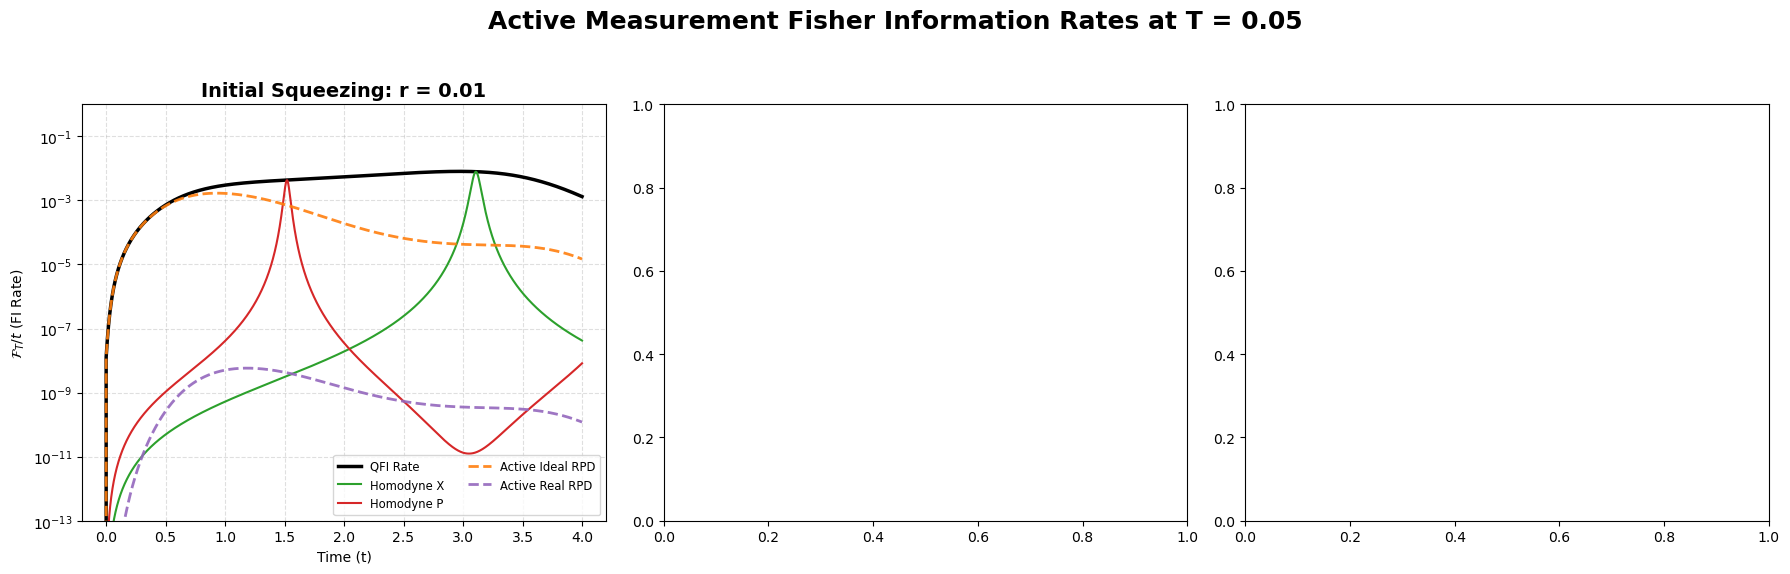

In [ ]:
def generate_sigma0(r, theta):
    """
    Generates the rotated squeezed covariance matrix.
    r: squeezing magnitude (r < 1 position squeezed, r > 1 momentum squeezed)
    theta: squeezing angle in radians
    """
    # Base squeezed state (diagonal)
    sigma_base = 0.5 * np.array([[r, 0], 
                                 [0, 1.0/r]])
    
    # Rotation matrix
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, s], 
                  [-s, c]])
    
    # Apply rotation: R * sigma_base * R^T
    sigma0 = R @ sigma_base @ R.T
    return sigma0


def evolve_all_FI_dynamics(t_array, x0, p0, sigma0, alpha1, alpha2, Temp, gamma, G, Gdot, Gddot, Omega_S, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real
    
    # System contribution to Covariance
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    # Arrays to store tracking variables (Values and Rates)
    FI_het, FI_hom_x, FI_hom_p, QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    FI_rpd_ideal, FI_rpd_real = np.zeros(N), np.zeros(N)
    
    rate_het, rate_hom_x, rate_hom_p, rate_QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    rate_rpd_ideal, rate_rpd_real = np.zeros(N), np.zeros(N)
    
    # Define Measurement Matrices for standard Gaussian Measurements
    sig_M_het = np.array([[0.5, 0.0], [0.0, 0.5]])
    sig_M_hom_x = np.array([[1e-9, 0.0], [0.0, 1e9]])
    sig_M_hom_p = np.array([[1e9, 0.0], [0.0, 1e-9]])
    
    def calc_classical_CFI(sig, dsig, sig_M):
        inv_term = np.linalg.inv(sig + sig_M)
        prod = np.dot(inv_term, dsig)
        return 0.5 * np.trace(np.dot(prod, prod))

    for i in tqdm(range(1, N), desc="Simulating Dynamics & FIs"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        t_current = t_array[i]
        
        # Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # 1. Classical FIs (Standard Gaussian Protocols)
        FI_het[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_het)
        FI_hom_x[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_x)
        FI_hom_p[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_p)
        
        # --- 2. Active Photodetection FIs (Ideal & Realistic) ---
        # --- DYNAMIC ADAPTATION ---
        # 1. Calculate the free rotation angle at the current time
        phase = Omega_S * t_current
        c_rot = np.cos(phase)
        s_rot = np.sin(phase)
        
        # 2. Build the symplectic rotation matrix for the free oscillator
        S_rot = np.array([
            [c_rot,              s_rot / Omega_S],
            [-Omega_S * s_rot,   c_rot          ]
        ])
        
        # 3. Rotate the measurement basis to track the state
        sigma_M_adaptive = S_rot @ sigma0 @ S_rot.T
        
        # 4. Use the adaptive matrix for photodetection
        A_rpd = sigma_t + sigma_M_adaptive
        det_A = np.linalg.det(A_rpd)
        inv_A = np.linalg.inv(A_rpd)
        trace_term = np.trace(np.dot(inv_A, dsigma_t))
        
        P_0_base = 1.0 / np.sqrt(det_A)
        
        # Ideal Active RPD (P_D = 0)
        dP_0_ideal = -0.5 * P_0_base * trace_term
        FI_rpd_ideal[i] = (dP_0_ideal**2) / (P_0_base * (1.0 - P_0_base) + 1e-15)
        
        # Realistic Active RPD (P_D = 0.02)
        P_D = 0.99999
        P_0_real = (1.0 - P_D) * P_0_base
        dP_0_real = -0.5 * P_0_real * trace_term
        FI_rpd_real[i] = (dP_0_real**2) / (P_0_real * (1.0 - P_0_real) + 1e-15)

        # --- 3. Quantum FI (Using Analytical Formula from Appendix B) ---
                
        # 3.a) Calculate determinants explicitly for 2x2 matrices
        det_sigma = sigma_t[0,0]*sigma_t[1,1] - sigma_t[0,1]**2
        det_dsigma = dsigma_t[0,0]*dsigma_t[1,1] - dsigma_t[0,1]**2
        
        # 3.b) Calculate the temperature derivative of the determinant (Eq. B15)
        d_det_sigma = dsigma_t[0,0]*sigma_t[1,1] + sigma_t[0,0]*dsigma_t[1,1] - 2*sigma_t[0,1]*dsigma_t[0,1]
        
        # 3.c) Apply Eq. (B20)
        # We use a tiny epsilon max-gate to prevent strict ZeroDivision at exactly t=0
        # since det_sigma approaches 0.25 for pure states.
        epsilon = 1e-16 
        purity_term = np.maximum(det_sigma - 0.25, epsilon)
        
        term1 = 0.5 * (d_det_sigma**2) / (purity_term * (det_sigma + 0.25))
        term2 = det_dsigma / (det_sigma + 0.25)
        
        QFI[i] = term1 - term2
        
        # 4. Calculate Rates directly
        rate_het[i] = FI_het[i] / t_current
        rate_hom_x[i] = FI_hom_x[i] / t_current
        rate_hom_p[i] = FI_hom_p[i] / t_current
        rate_rpd_ideal[i] = FI_rpd_ideal[i] / t_current
        rate_rpd_real[i] = FI_rpd_real[i] / t_current
        rate_QFI[i] = QFI[i] / t_current
        
    return {
        "time": t_array, 
        "rate_het": rate_het, "rate_hom_x": rate_hom_x, "rate_hom_p": rate_hom_p, 
        "rate_rpd_ideal": rate_rpd_ideal, "rate_rpd_real": rate_rpd_real, "rate_QFI": rate_QFI
    }

# ==========================================
# 4. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # --- Physical Parameters ---
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 2.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    mass = 1.0
    
    # Simulation Time Grid
    times = np.linspace(0, 4, 3000)
    
    # Laplace Polynomials for the Green's Function
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    # Extract Green's Function and Derivatives (assuming dependencies are met)
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
    Gdot = Gprime_of_t  
    
    x0 = 1.0
    p0 = 0.0

    # ---------------------------------------------------------
    # NEW SETUP: Fixed T, 3 squeezing values, unified execution
    # ---------------------------------------------------------
    T_fixed = 0.05  
    r_values = [1e2]
    theta = 0.0

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Active Measurement Fisher Information Rates at T = {T_fixed}", fontsize=18, fontweight='bold')
    axes = axes.flatten()
    
    for i, (r, ax) in enumerate(zip(r_values, axes)):
        print(f"\n--- Simulating for Squeezing r = {r} ---")
        
        # Generate initial state
        sigma0 = generate_sigma0(r, theta)
        
        sol = evolve_all_FI_dynamics( times, x0, p0, sigma0, alpha1, alpha2, T_fixed, gamma, G, Gdot, Gddot, Omega_S, mass)
        
        # 1. Plot QFI (Absolute Quantum Bound)
        ax.plot(sol["time"], sol["rate_QFI"], color='black', linewidth=2.5, label="QFI Rate")
        
        # 2. Plot Gaussian Measurements
        #ax.plot(sol["time"], sol["rate_het"], color='tab:blue', linewidth=1.5, label="Heterodyne")
        ax.plot(sol["time"], sol["rate_hom_x"], color='tab:green', linewidth=1.5, label="Homodyne X")
        ax.plot(sol["time"], sol["rate_hom_p"], color='tab:red', linewidth=1.5, label="Homodyne P")
        
        # 3. Plot Photodetection (Light dashed lines)
        ax.plot(sol["time"], sol["rate_rpd_ideal"], color='tab:orange', linestyle='--', alpha=0.9, linewidth=2, label="Active Ideal RPD")
        ax.plot(sol["time"], sol["rate_rpd_real"], color='tab:purple', linestyle='--', alpha=0.9, linewidth=2, label="Active Real RPD")
        
        # Formatting the subplot
        ax.set_title(f"Initial Squeezing: r = {r}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Time (t)")
        ax.set_ylabel(r"$\mathcal{F}_T / t$ (FI Rate)")
        
        # Log scale handles rates spanning multiple orders of magnitude
        ax.set_yscale('log')
        ax.set_ylim(1e-13, 1)
        ax.grid(True, which="both", ls="--", alpha=0.4)
        
        ax.legend(loc='lower right', fontsize='small', ncol=2)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Green Function plots

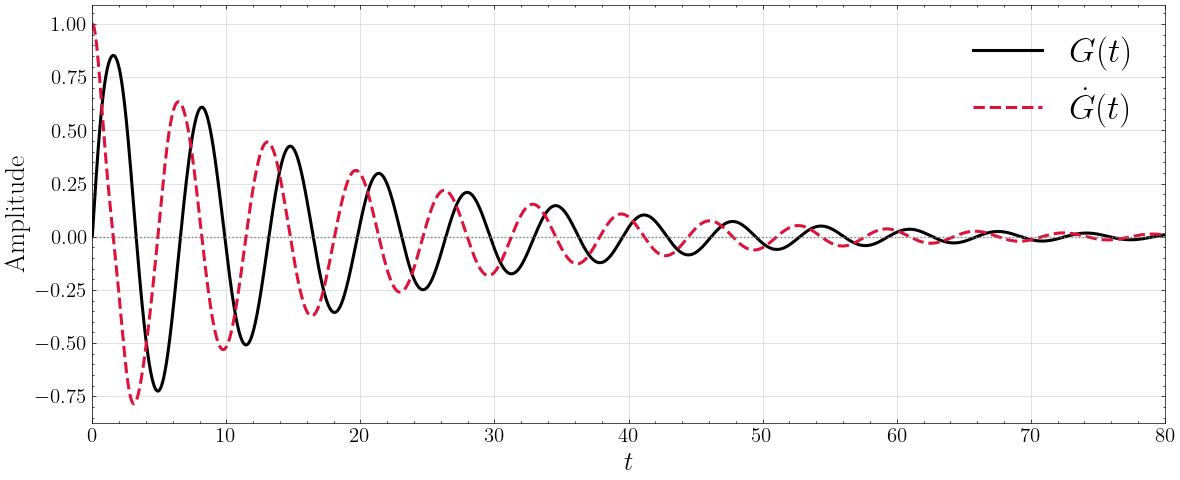

In [14]:
import numpy as np
import matplotlib.pyplot as plt


# --- Assume these are defined elsewhere in your script ---
# def inverse_laplace_rational(B, A): ...
# def derivatives_from_residues(times, residues, poles): ...

plt.style.use(["science"])
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams.update({
    "axes.labelsize": 26,    # x- and y-label size
    "axes.titlesize": 18,    # title size
    "xtick.labelsize": 24,   # x-tick label size
    "ytick.labelsize": 24,   # y-tick label size
    "legend.fontsize": 24,   # legend text size
})

if __name__ == "__main__":
    # --- Physical Parameters ---
    gamma = 1.0
    alpha1 = 1.0
    alpha2 = 10.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    mass = 1.0
    
    # Simulation Time Grid
    times = np.linspace(0, 80, 5000)
    
    # Laplace Polynomials for the Green's Function
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    # Extract Green's Function and Derivatives (assuming dependencies are met)
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
    Gdot = Gprime_of_t 
    
    # --- Plotting ---
    # Use real parts in case of tiny numerical imaginary artifacts from the poles
    G_real = np.real(G)
    Gdot_real = np.real(Gdot)

    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Plot the functions
    ax.plot(times, G_real, label=r'$G(t)$', color='black', linewidth=2.2)
    ax.plot(times, Gdot_real, label=r'$\dot{G}(t)$', color='crimson', linestyle='--', linewidth=2.2)
    
    # Formatting the plot
    ax.axhline(0, color='gray', linewidth=1, linestyle=':') # Zero reference line
    ax.set_xlabel(r'$t$', fontsize=19)
    ax.set_ylabel('Amplitude', fontsize=20)
    
    # Customize ticks and grid
    ax.tick_params(axis='both', labelsize=15)
    ax.grid(True, linestyle='-', alpha=0.5)
    
    # Add Legend
    ax.legend(fontsize=25, loc='upper right', framealpha=0.9)
    
    # Set x-limits to match the simulation grid
    ax.set_xlim([0, times[-1]])
    
    plt.tight_layout()
    plt.show()

# GKLS vs Exact Covariances Plots

Simulating Exact Dynamics: 100%|██████████| 4999/4999 [00:10<00:00, 479.00it/s] 


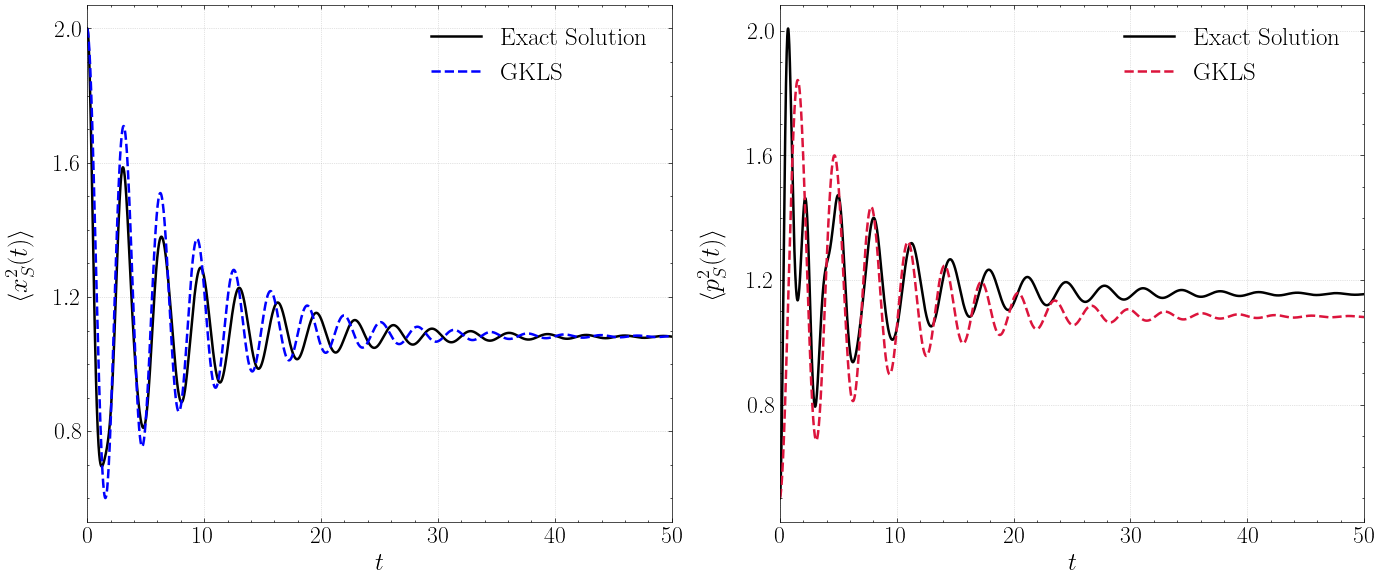

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from tqdm import tqdm

# ==========================================
# 1. EXTERNAL EXACT FUNCTIONS (From your library)
# ==========================================
# Make sure to import or define these from your existing exact solver script:
# from your_module import inverse_laplace_rational, derivatives_from_residues
# from your_module import noise_kernel_residue, dnu_dT_residue, matmul_toeplitz

# ==========================================
# 2. GKSL (MARKOVIAN) SOLVER FUNCTIONS
# ==========================================
def bose_occupation(omega, temp):
    return 1.0 / (np.exp(omega / temp) - 1.0)

def lamb_shift_value(Omega_S, Omega_RC, gamma, lam):
    return -(lam**2) * (Omega_RC**2 - Omega_S**2) / (
        (Omega_RC**2 - Omega_S**2)**2 + gamma**2 * Omega_S**2
    )

def lindblad_matrices_system(Omega_S, Omega_RC, kappa, temp, gamma, lam, include_ls=False):
    if include_ls:
        LS = lamb_shift_value(Omega_S, Omega_RC, gamma, lam)
    else:
        LS = 0.0

    N = bose_occupation(Omega_S, temp)
    A = np.array([
        [-kappa/2, 1.0 - LS / Omega_S**2],
        [-(Omega_S**2 - LS), -kappa/2]
    ], dtype=float)

    D = np.array([
        [kappa * (2*N + 1) / (2*Omega_S), 0.0],
        [0.0, Omega_S * kappa * (2*N + 1) / 2]
    ], dtype=float)

    return A, D

def lindblad_ode_system(y, t, A, D):
    mu = y[:2]
    sigma = y[2:].reshape((2, 2))
    d_mu = A @ mu
    d_sigma = A @ sigma + sigma @ A.T + D
    return np.concatenate([d_mu, d_sigma.reshape(-1)])

def solve_system_gksl(times, Omega_S, Omega_RC, kappa, temp, gamma, lam, mean0, sigma0, include_ls=False):
    A, D = lindblad_matrices_system(Omega_S, Omega_RC, kappa, temp, gamma, lam, include_ls=include_ls)
    mean0 = np.asarray(mean0, dtype=float)
    sigma0 = np.asarray(sigma0, dtype=float)
    y0 = np.concatenate([mean0, sigma0.reshape(-1)])
    sol = odeint(lindblad_ode_system, y0, times, args=(A, D))
    cov_t = sol[:, 2:].reshape(len(times), 2, 2)
    return cov_t

def spectral_density_original(omega, gamma, lam, Omega_RC):
    return gamma * lam**2 * omega / (gamma**2 * omega**2 + (Omega_RC**2 - omega**2)**2)


# ==========================================
# 3. EXACT (NON-MARKOVIAN) SOLVER FUNCTION
# ==========================================
def evolve_FI_dynamics(t_array, x0, p0, sigma0, sigma_M, alpha1, alpha2, Temp, gamma, G, Gdot, Gddot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real

    x_mean = Gdot_r * x0 + (G_r / mass) * p0
    p_mean = mass * Gddot_r * x0 + Gdot_r * p0
    
    # System contribution to Covariance
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    fisher_info_t = np.zeros(N)
    var_x_total = np.zeros(N)
    var_p_total = np.zeros(N)
    
    for i in tqdm(range(1, N), desc="Simulating Exact Dynamics"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        # Standard Covariance Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        var_x_total[i] = sigma_t[0, 0]
        var_p_total[i] = sigma_t[1, 1]
        
        # Derivative Covariance Integrals (Toeplitz)
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # Calculate Fisher Information Term
        inverse_term = np.linalg.inv(sigma_t + sigma_M)
        matrix_prod = np.dot(inverse_term, dsigma_t)
        fisher_info_t[i] = 0.5 * np.trace(np.dot(matrix_prod, matrix_prod))
            
    # Set t=0 values explicitly
    var_x_total[0] = sx0
    var_p_total[0] = sp0
            
    return {"time": t_array, "var_x": var_x_total, "var_p": var_p_total, "FI": fisher_info_t}


# ==========================================
# 4. EXECUTION & PLOTTING BLOCK
# ==========================================
if __name__ == "__main__":
    # --- Physical Parameters ---
    gamma = 1.0
    alpha1 = 1  # Using 0.1 for a clearer strong-coupling deviation
    alpha2 = 10.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    temp = 1.0
    mass = 1.0
    
    # GKSL translated parameters
    lam = np.sqrt(alpha1 * alpha2)
    Omega_RC = np.sqrt(alpha2 * gamma)

    # Simulation Time Grid
    times = np.linspace(0, 50, 5000)

    # Initial State (Zero displacement, defined squeezing)
    x0, p0 = 0.0, 0.0
    mean0 = np.array([x0, p0])
    sigma0 = np.array([
        [2.0 / Omega_S_bare, 0.0], 
        [0.0, Omega_S_bare / 2.0]
    ])
    
    # Dummy measurement matrix (Needed to run exact FI code, though we only plot variances)
    sigma_M = np.array([[0.5, 0.0], [0.0, 0.5]])

    # ---------------------------------------------------------
    # RUN GKSL (MARKOVIAN)
    # ---------------------------------------------------------
    kappa = spectral_density_original(Omega_S_bare, gamma, lam, Omega_RC) / Omega_S_bare
    cov_t_local = solve_system_gksl(times, Omega_S_bare, Omega_RC, kappa, temp, gamma, lam, mean0, sigma0, include_ls=False)
    
    var_x_gksl = cov_t_local[:, 0, 0]
    var_p_gksl = cov_t_local[:, 1, 1]

    # ---------------------------------------------------------
    # RUN EXACT (NON-MARKOVIAN)
    # ---------------------------------------------------------
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
    
    sol_exact = evolve_FI_dynamics(times, x0, p0, sigma0, sigma_M, alpha1, alpha2, temp, gamma, G, Gprime_of_t, Gddot, mass)

    # ---------------------------------------------------------
    # PLOTTING
    # ---------------------------------------------------------
    
    from matplotlib.ticker import MultipleLocator

# Figure: Position and Momentum Variances
fig, (ax_x, ax_p) = plt.subplots(1, 2, figsize=(14, 6))

# --- Position Variance ---
ax_x.plot(times, sol_exact["var_x"], 
          label='Exact Solution', color='black', lw=1.8)
ax_x.plot(times, var_x_gksl, 
          label='GKLS', color='blue', linestyle='--', lw=1.8)
ax_x.set_xlabel(r'$t$', fontsize=18)
ax_x.set_ylabel(r'$\langle x_S^2(t) \rangle$', 
                fontsize=19, labelpad=15)
ax_x.yaxis.set_major_locator(MultipleLocator(0.4))
ax_x.tick_params(axis='both', which='major', labelsize=17)
ax_x.legend(fontsize=18)
ax_x.grid(True, linestyle=':', alpha=0.7)
ax_x.set_xlim([0, times[-1]])


# --- Momentum Variance ---
ax_p.plot(times, sol_exact["var_p"], 
          label='Exact Solution', color='black', lw=1.8)
ax_p.plot(times, var_p_gksl, 
          label='GKLS', color='crimson', linestyle='--', lw=1.8)
ax_p.set_xlabel(r'$t$', fontsize=18)
ax_p.set_ylabel(r'$\langle p_S^2(t) \rangle$', 
                fontsize=19, labelpad=15)

# Números del eje Y cada 0.4
ax_p.yaxis.set_major_locator(MultipleLocator(0.4))
ax_p.tick_params(axis='both', which='major', labelsize=17)
ax_p.legend(fontsize=18)
ax_p.grid(True, linestyle=':', alpha=0.7)
ax_p.set_xlim([0, times[-1]])


# Ajustar espacios
fig.tight_layout()

plt.show()